# 🛒 **FMCG Retail Analytics & Customer Segmentation**

# OVERVIEW

🗂️ Project Summary

This EDA notebook analyzes Xóm Mart’s 4-month transaction dataset from 2018 (~6.75 million rows) across its global FMCG retail network. The primary objective is to uncover sales patterns, customer behavior, and operational trends to inform business decisions.

- Data Cleaning & Checking: checked data types, fixed errors, handled missing values.

- Univariate & Bivariate Analysis: explored distributions (revenue, quantity, price, discount), product/ category/city breakdowns.

- Time-Series & Geographic Analysis: tracked sales trends over time (monthly, weekly patterns) and mapped revenue across 96 cities to identify core growth markets.

- Correlation: assessed relationships between key metrics and clustered categories by revenue vs. quantity.

- Customer Segmentation: segmented customers by total spend and purchasing behavior to pinpoint high-value groups.

- Cashier Performance: evaluated sales created by 23 key cashiers to see if a few staff bring in most of the revenue.



# 1. Import Libraries

In [1]:
# Data manipulation libraries
import pandas as pd 
import numpy as np 

# Data visualization libraries
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns

from datetime import datetime
# Database Interaction
from sqlalchemy import create_engine

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option("display.max_colwidth", None) # To set the width of the column to maximum
pd.set_option("display.max_columns", None) # To display all the columns of dataframe
pd.set_option('display.max_info_columns', 100000) # To display all columns when use .info()

# 2. Load data

In [2]:
# Load dataset

df_categories = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\categories.csv')
df_cities = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\cities.csv')
df_countries = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\countries.csv')
df_customers = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\customers.csv')
df_employees = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\employees.csv')
df_products = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\products.csv')
df_sales = pd.read_csv(r'E:\01. Portfolio\Projects\local\02-retail-analytics\Dataset\sales.csv')

# 3. Data Profiling

In [3]:
# QUICK SHAPE OVERVIEW
print(f"df_categories shape: {df_categories.shape}")
print(f"df_cities shape: {df_cities.shape}")
print(f"df_countries shape: {df_countries.shape}")
print(f"df_customers shape: {df_customers.shape}")
print(f"df_employees shape: {df_employees.shape}")
print(f"df_products shape: {df_products.shape}")
print(f"df_sales shape: {df_sales.shape}")

df_categories shape: (11, 2)
df_cities shape: (96, 4)
df_countries shape: (206, 3)
df_customers shape: (98759, 6)
df_employees shape: (23, 8)
df_products shape: (452, 9)
df_sales shape: (6758125, 9)


## 3.1. Quick view of all Dataframes

In [ ]:
# QUICK VIEW OF ALL DATAFRAMES

print("df_categories")
display(df_categories.head())
# print()

print("\n df_cities")
display(df_cities.head())

print("\n df_countries")
display(df_countries.head())

print("\n df_customers")
display(df_customers.head())

print("\n df_employees")
display(df_employees.head())

print("\n df_products")
display(df_products.head())

print("\n df_sales")
display(df_sales.head())

df_categories


,CategoryID,CategoryName
0,1,Confections
1,2,Shell fish
2,3,Cereals
3,4,Dairy
4,5,Beverages



 df_cities


,CityID,CityName,Zipcode,CountryID
0,1,Dayton,80563,32
1,2,Buffalo,17420,32
2,3,Chicago,44751,32
3,4,Fremont,20641,32
4,5,Virginia Beach,62389,32



 df_countries


...

,EmployeeID,FirstName,MiddleInitial,LastName,BirthDate,Gender,CityID,HireDate
0,1,Nicole,T,Fuller,1981-03-07 00:00:00.000,F,80,2011-06-20 07:15:36.920
1,2,Christine,W,Palmer,1968-01-25 00:00:00.000,F,4,2011-04-27 04:07:56.930
2,3,Pablo,Y,Cline,1963-02-09 00:00:00.000,M,70,2012-03-30 18:55:23.270
3,4,Darnell,O,Nielsen,1989-02-06 00:00:00.000,M,39,2014-03-06 06:55:02.780
4,5,Desiree,L,Stuart,1963-05-03 00:00:00.000,F,23,2014-11-16 22:59:54.720



 df_products


,ProductID,ProductName,Price,CategoryID,Class,ModifyDate,Resistant,IsAllergic,VitalityDays
0,1,Flour - Whole Wheat,74.30,3,Medium,2018-02-16 08:21:49.190,Durable,Unknown,0.00
1,2,Cookie Chocolate Chip With,91.23,3,Medium,2017-02-12 11:39:10.970,Unknown,Unknown,0.00
2,3,Onions - Cippolini,9.14,9,Medium,2018-03-15 08:11:51.560,Weak,False,111.00
3,4,"Sauce - Gravy, Au Jus, Mix",54.31,9,Medium,2017-07-16 00:46:28.880,Durable,Unknown,0.00
4,5,Artichokes - Jerusalem,65.48,2,Low,2017-08-16 14:13:35.430,Durable,True,27.00



 df_sales


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber
0,1,6,27039,381,7,0.00,0.00,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G
1,2,16,25011,61,7,0.00,0.00,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8
2,3,13,94024,23,24,0.00,0.00,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0
3,4,8,73966,176,19,0.20,0.00,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE
4,5,10,32653,310,9,0.00,0.00,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3


## 3.2. Info of Dataframes

In [5]:
print("df_categories")
display(df_categories.info())


print("\n df_cities")
display(df_cities.info())

print("\n df_countries")
display(df_countries.info())

print("\n df_customers")
display(df_customers.info())

print("\n df_employees")
display(df_employees.info())

print("\n df_products")
display(df_products.info())

print("\n df_sales")
display(df_sales.info(show_counts=all))

df_categories
<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CategoryID    11 non-null     int64
 1   CategoryName  11 non-null     str  
dtypes: int64(1), str(1)
memory usage: 308.0 bytes


None


 df_cities
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   CityID     96 non-null     int64
 1   CityName   96 non-null     str  
 2   Zipcode    96 non-null     int64
 3   CountryID  96 non-null     int64
dtypes: int64(3), str(1)
memory usage: 3.1 KB


None


 df_countries
<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   CountryID    206 non-null    int64
 1   CountryName  206 non-null    str  
 2   CountryCode  205 non-null    str  
dtypes: int64(1), str(2)
memory usage: 5.0 KB


...

None


 df_products
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     452 non-null    int64  
 1   ProductName   452 non-null    str    
 2   Price         452 non-null    float64
 3   CategoryID    452 non-null    int64  
 4   Class         452 non-null    str    
 5   ModifyDate    452 non-null    str    
 6   Resistant     452 non-null    str    
 7   IsAllergic    452 non-null    str    
 8   VitalityDays  452 non-null    float64
dtypes: float64(2), int64(2), str(5)
memory usage: 31.9 KB


None


 df_sales
<class 'pandas.DataFrame'>
RangeIndex: 6758125 entries, 0 to 6758124
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   SalesID            6758125 non-null  int64  
 1   SalesPersonID      6758125 non-null  int64  
 2   CustomerID         6758125 non-null  int64  
 3   ProductID          6758125 non-null  int64  
 4   Quantity           6758125 non-null  int64  
 5   Discount           6758125 non-null  float64
 6   TotalPrice         6758125 non-null  float64
 7   SalesDate          6690599 non-null  str    
 8   TransactionNumber  6758125 non-null  str    
dtypes: float64(2), int64(5), str(2)
memory usage: 464.0 MB


None

In [6]:
df_countries[df_countries['CountryCode'].isna()]

,CountryID,CountryName,CountryCode
145,146,Australia,NaN


In [7]:
# Change CountryCode of Australia
df_countries.loc[49,'CountryCode'] = 'AR'
df_countries.loc[145,'CountryCode'] = 'AU'

In [8]:
df_countries.isnull().sum()

CountryID      0
CountryName    0
CountryCode    0
dtype: int64

In [9]:
# Convert str to Date
df_employees['BirthDate'] = df_employees['BirthDate'].astype('datetime64[ns]')
df_employees['HireDate'] = df_employees['HireDate'].astype('datetime64[ns]')
df_products['ModifyDate'] = df_products['ModifyDate'].astype('datetime64[ns]')
df_sales['SalesDate'] = df_sales['SalesDate'].astype('datetime64[ns]', errors='ignore')

In [10]:
print("\n df_employees")
display(df_employees.info())

print("\n df_products")
display(df_products.info())

print("\n df_sales")
display(df_sales.info(show_counts=all))


 df_employees
<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EmployeeID     23 non-null     int64         
 1   FirstName      23 non-null     str           
 2   MiddleInitial  23 non-null     str           
 3   LastName       23 non-null     str           
 4   BirthDate      23 non-null     datetime64[ns]
 5   Gender         23 non-null     str           
 6   CityID         23 non-null     int64         
 7   HireDate       23 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), str(4)
memory usage: 1.6 KB


None


 df_products
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ProductID     452 non-null    int64         
 1   ProductName   452 non-null    str           
 2   Price         452 non-null    float64       
 3   CategoryID    452 non-null    int64         
 4   Class         452 non-null    str           
 5   ModifyDate    452 non-null    datetime64[ns]
 6   Resistant     452 non-null    str           
 7   IsAllergic    452 non-null    str           
 8   VitalityDays  452 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), str(4)
memory usage: 31.9 KB


None


 df_sales
<class 'pandas.DataFrame'>
RangeIndex: 6758125 entries, 0 to 6758124
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   SalesID            6758125 non-null  int64         
 1   SalesPersonID      6758125 non-null  int64         
 2   CustomerID         6758125 non-null  int64         
 3   ProductID          6758125 non-null  int64         
 4   Quantity           6758125 non-null  int64         
 5   Discount           6758125 non-null  float64       
 6   TotalPrice         6758125 non-null  float64       
 7   SalesDate          6690599 non-null  datetime64[ns]
 8   TransactionNumber  6758125 non-null  str           
dtypes: datetime64[ns](1), float64(2), int64(5), str(1)
memory usage: 464.0 MB


None

In [11]:
df_sales.isnull().sum()

SalesID                  0
SalesPersonID            0
CustomerID               0
ProductID                0
Quantity                 0
Discount                 0
TotalPrice               0
SalesDate            67526
TransactionNumber        0
dtype: int64

In [12]:
# Checking dupliacte values
print('df_categories:', df_categories.duplicated().sum())
print('df_cities:', df_cities.duplicated().sum())
print('df_countries:', df_countries.duplicated().sum())
print('df_customers:', df_customers.duplicated().sum())
print('df_employees:', df_employees.duplicated().sum())
print('df_products:', df_products.duplicated().sum())
print('df_sales:', df_sales.duplicated().sum())

df_categories: 0
df_cities: 0
df_countries: 0
df_customers: 0
df_employees: 0
df_products: 0
df_sales: 0


The dataframes contain some errors:
- df_countries have 1 missing values in column "CountryCode".
- In df_employees have column "HireDate", "BirthDate", df_products have column "ModifyDate" is in dtype = 'str', not datetime64.
- df_Sales have 67526 missing values in column "SalesDate".

# 4. Data Wrangling

In [13]:
# Concat string to create full name columns
full_name = ['FirstName', 'MiddleInitial', 'LastName']

df_customers['full_name'] = df_customers[full_name].agg(lambda x: ' '.join(x.dropna()), axis=1)
df_employees['full_name'] = df_employees[full_name].agg(lambda x: ' '.join(x.dropna()), axis=1)

In [14]:
df_customers.head()

,CustomerID,FirstName,MiddleInitial,LastName,CityID,Address,full_name
0,1,Stefanie,Y,Frye,79,97 Oak Avenue,Stefanie Y Frye
1,2,Sandy,T,Kirby,96,52 White First Freeway,Sandy T Kirby
2,3,Lee,T,Zhang,55,921 White Fabien Avenue,Lee T Zhang
3,4,Regina,S,Avery,40,75 Old Avenue,Regina S Avery
4,5,Daniel,S,Mccann,2,283 South Green Hague Avenue,Daniel S Mccann


In [15]:
# Merge df_categories with df_products
df_products_full = pd.merge(df_products, df_categories, how='left', on='CategoryID')

# Merge df_countries with df_cities
df_cities_full = pd.merge(df_cities, df_countries, how='left', on='CountryID')

# Merge df_customers with df_cities
df_customers_full = pd.merge(df_customers, df_cities_full, how='left', on='CityID')
df_customers_full = df_customers_full.drop(columns=full_name, errors='ignore')
df_customers_full = df_customers_full.add_suffix('_customer')


# Merge df_employees with df_cities
df_employees_full = pd.merge(df_employees, df_cities_full, how='left', on='CityID')
df_employees_full = df_employees_full.drop(columns=full_name, errors='ignore')
df_employees_full = df_employees_full.add_suffix('_employee')

# Merge df_sales with df_customers and df_employees
df = pd.merge(df_sales, df_customers_full, how='left', left_on='CustomerID', right_on= 'CustomerID_customer')
df = pd.merge(df, df_employees_full, how='left', left_on='SalesPersonID', right_on = "EmployeeID_employee")
df = pd.merge(df, df_products_full, how='left', on='ProductID')


# Clean up redundant columns
cols_to_drop = ['CustomerID_customer', 'CityID_customer', 'Zipcode_customer', 'CountryID_customer', 'CountryCode_customer', 'EmployeeID_employee', 'CityID_employee', 'Zipcode_employee', 'CountryID_employee', 'CountryCode_employee', 'CategoryID']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.head()




,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,Address_customer,full_name_customer,CityName_customer,CountryName_customer,BirthDate_employee,Gender_employee,HireDate_employee,full_name_employee,CityName_employee,CountryName_employee,ProductName,Price,Class,ModifyDate,Resistant,IsAllergic,VitalityDays,CategoryName
0,1,6,27039,381,7,0.00,0.00,2018-02-05 07:38:25.430,FQL4S94E4ME1EZFTG42G,826 Rocky Second Freeway,Susan V Green,Albuquerque,United States,1987-01-13,M,2013-06-22 13:20:18.080,Holly E Collins,Baltimore,United States,Vaccum Bag 10x13,44.23,High,2018-01-06 22:26:53.580,Unknown,Unknown,41.00,Confections
1,2,16,25011,61,7,0.00,0.00,2018-02-02 16:03:31.150,12UGLX40DJ1A5DTFBHB8,334 Cowley Street,Telly W Pollard,Phoenix,United States,1951-07-07,M,2017-02-10 11:21:26.650,Chadwick U Walton,Tucson,United States,Sardines,62.55,Low,2017-12-03 21:41:12.420,Durable,False,90.00,Grain
2,3,13,94024,23,24,0.00,0.00,2018-05-03 19:31:56.880,5DT8RCPL87KI5EORO7B0,537 First St.,Jon K Rangel,Buffalo,United States,1963-04-18,M,2011-12-12 10:43:52.940,Katina Y Marks,Anchorage,United States,Crab - Imitation Flakes,79.02,Medium,2017-08-19 07:18:29.890,Durable,True,0.00,Produce
3,4,8,73966,176,19,0.20,0.00,2018-04-07 14:43:55.420,R3DR9MLD5NR76VO17ULE,41 Hague Way,Carol V Gilmore,Dallas,United States,1956-12-13,M,2014-10-14 23:12:53.420,Julie E Dyer,Little Rock,United States,Smirnoff Green Apple Twist,81.32,High,2017-08-27 17:08:59.840,Durable,True,90.00,Seafood
4,5,10,32653,310,9,0.00,0.00,2018-02-12 15:37:03.940,4BGS0Z5OMAZ8NDAFHHP3,18 East Second Boulevard,Terra V Carter,Charlotte,United States,1963-12-30,M,2012-07-23 15:02:12.640,Jean P Vang,Atlanta,United States,Coffee - Dark Roast,79.98,Low,2018-01-14 19:33:15.530,Weak,False,0.00,Poultry


In [16]:
df.info(show_counts=all)

<class 'pandas.DataFrame'>
RangeIndex: 6758125 entries, 0 to 6758124
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   SalesID               6758125 non-null  int64         
 1   SalesPersonID         6758125 non-null  int64         
 2   CustomerID            6758125 non-null  int64         
 3   ProductID             6758125 non-null  int64         
 4   Quantity              6758125 non-null  int64         
 5   Discount              6758125 non-null  float64       
 6   TotalPrice            6758125 non-null  float64       
 7   SalesDate             6690599 non-null  datetime64[ns]
 8   TransactionNumber     6758125 non-null  str           
 9   Address_customer      6758125 non-null  str           
 10  full_name_customer    6758125 non-null  str           
 11  CityName_customer     6758125 non-null  str           
 12  CountryName_customer  6758125 non-null  str          

In [17]:
df.describe()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,BirthDate_employee,HireDate_employee,Price,ModifyDate,VitalityDays
count,"6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00",6690599,6758125,6758125,"6,758,125.00",6758125,"6,758,125.00"
mean,"3,379,063.00",12.00,"49,395.67",226.55,13.00,0.03,0.00,2018-03-06 12:28:36.599011840,1967-11-28 23:11:45.730243160,2013-08-17 03:43:13.492659712,50.82,2017-09-11 19:54:37.348812800,26.04
min,1.00,1.00,1.00,1.00,1.00,0.00,0.00,2018-01-01 00:00:04.070000,1951-07-07 00:00:00,2010-02-22 21:55:48.620000,0.04,2017-01-03 12:21:41.850000,0.00
25%,"1,689,532.00",6.00,"24,707.00",114.00,7.00,0.00,0.00,2018-02-02 06:29:42.464999936,1961-09-05 00:00:00,2011-11-03 00:44:25.390000128,26.58,2017-05-16 21:30:57.529999872,0.00
50%,"3,379,063.00",12.00,"49,414.00",227.00,13.00,0.00,0.00,2018-03-06 13:05:36.860000,1964-06-13 00:00:00,2013-06-22 13:20:18.080000,52.64,2017-09-14 03:43:07.710000128,0.00
75%,"5,068,594.00",18.00,"74,075.00",340.00,19.00,0.00,0.00,2018-04-07 18:07:28.464999936,1976-01-14 00:00:00,2015-11-25 18:18:23.480000,75.25,2018-01-13 17:45:18.720000,52.00
max,"6,758,125.00",23.00,"98,759.00",452.00,25.00,0.20,0.00,2018-05-09 23:59:59.400000,1989-08-29 00:00:00,2017-02-10 11:21:26.650000,99.88,2018-05-09 20:18:03.820000,120.00
std,"1,950,902.79",6.63,"28,505.04",130.47,7.21,0.06,0.00,NaN,NaN,NaN,28.57,NaN,39.03


In [18]:
df = df.drop(columns= ['TotalPrice'])

In [19]:
def  check_outlier(list_feature, df, dataset_name):
    print(f"[i] {dataset_name} Checking outliers")
    outlier_info = []

    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 - 1.5 * IQR 

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]

        if len(outliers) > 0:
            outlier_info.append(
                {"Feature": feature,
                "Outlier count": len(outliers)
                }
            )
    
    if len(outlier_info) == 0:
        print("No outliers deleted")
    else:
        return pd.DataFrame(outlier_info)


In [20]:
num_feature = ['Quantity', 'Discount', 'Price']
check_outlier(list_feature=num_feature, df=df, dataset_name="Master data")

[i] Master data Checking outliers


,Feature,Outlier count
0,Quantity,6488431
1,Discount,1351194
2,Price,6638692


In [21]:
df.isnull().sum()

SalesID                     0
SalesPersonID               0
CustomerID                  0
ProductID                   0
Quantity                    0
Discount                    0
SalesDate               67526
TransactionNumber           0
Address_customer            0
full_name_customer          0
CityName_customer           0
CountryName_customer        0
BirthDate_employee          0
Gender_employee             0
HireDate_employee           0
full_name_employee          0
CityName_employee           0
CountryName_employee        0
ProductName                 0
Price                       0
Class                       0
ModifyDate                  0
Resistant                   0
IsAllergic                  0
VitalityDays                0
CategoryName                0
dtype: int64

**Summary**
- Identified outliers in the dataset, but retained all values to reflect reality.

# 5. Feature Engineering

Create new columns based on existing columns:
- total_revenue = Quantity * Price
- total_revenue_after_discount = Quantity * Price * (1 - Discount)
- Extract information from SalesDate: year, quarter, month, WeekDay
- yoe_employee = MaxDate - HireDate
- sales_time = Extract time from SalesDate: HH:mm
- full_name_customer = 'FirstName' + 'MiddleInitial' + 'LastName'
- full_name_employee = 'FirstName' + 'MiddleInitial' + 'LastName'

In [22]:
df['total_revenue'] = df['Quantity'] * df['Price']
df['total_revenue_after_discount'] = df['Quantity'] * df['Price'] * (1 - df['Discount'])
df['sales_year'] = df['SalesDate'].dt.year.astype('Int64')
df['sales_quarter'] = df['SalesDate'].dt.quarter.astype('Int64')
df['sales_month_num'] = df['SalesDate'].dt.month.astype('Int64')
df['sales_month_name'] = df['SalesDate'].dt.month_name()
df['sales_weekday'] = df['SalesDate'].dt.day_name()
df['sales_time'] = df['SalesDate'].dt.strftime('%H:%M')
max_sales_date = df['SalesDate'].max()
df['yoe_employee'] = round((max_sales_date - df['HireDate_employee']).dt.days/365, 0)



In [23]:
df.describe()

,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,SalesDate,BirthDate_employee,HireDate_employee,Price,ModifyDate,VitalityDays,total_revenue,total_revenue_after_discount,sales_year,sales_quarter,sales_month_num,yoe_employee
count,"6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00","6,758,125.00",6690599,6758125,6758125,"6,758,125.00",6758125,"6,758,125.00","6,758,125.00","6,758,125.00","6,690,599.00","6,690,599.00","6,690,599.00","6,758,125.00"
mean,"3,379,063.00",12.00,"49,395.67",226.55,13.00,0.03,2018-03-06 12:28:36.599011840,1967-11-28 23:11:45.730243160,2013-08-17 03:43:13.492659712,50.82,2017-09-11 19:54:37.348812800,26.04,660.87,641.07,"2,018.00",1.30,2.67,4.69
min,1.00,1.00,1.00,1.00,1.00,0.00,2018-01-01 00:00:04.070000,1951-07-07 00:00:00,2010-02-22 21:55:48.620000,0.04,2017-01-03 12:21:41.850000,0.00,0.04,0.04,"2,018.00",1.00,1.00,1.00
25%,"1,689,532.00",6.00,"24,707.00",114.00,7.00,0.00,2018-02-02 06:29:42.464999936,1961-09-05 00:00:00,2011-11-03 00:44:25.390000128,26.58,2017-05-16 21:30:57.529999872,0.00,186.78,180.65,"2,018.00",1.00,2.00,2.00
50%,"3,379,063.00",12.00,"49,414.00",227.00,13.00,0.00,2018-03-06 13:05:36.860000,1964-06-13 00:00:00,2013-06-22 13:20:18.080000,52.64,2017-09-14 03:43:07.710000128,0.00,507.33,490.77,"2,018.00",1.00,3.00,5.00
75%,"5,068,594.00",18.00,"74,075.00",340.00,19.00,0.00,2018-04-07 18:07:28.464999936,1976-01-14 00:00:00,2015-11-25 18:18:23.480000,75.25,2018-01-13 17:45:18.720000,52.00,"1,017.35",983.74,"2,018.00",2.00,4.00,7.00
max,"6,758,125.00",23.00,"98,759.00",452.00,25.00,0.20,2018-05-09 23:59:59.400000,1989-08-29 00:00:00,2017-02-10 11:21:26.650000,99.88,2018-05-09 20:18:03.820000,120.00,"2,496.89","2,496.89","2,018.00",2.00,5.00,8.00
std,"1,950,902.79",6.63,"28,505.04",130.47,7.21,0.06,NaN,NaN,NaN,28.57,NaN,39.03,561.04,547.06,0.00,0.46,1.26,2.18


In [24]:
df.describe(include='O')

,TransactionNumber,Address_customer,full_name_customer,CityName_customer,CountryName_customer,Gender_employee,full_name_employee,CityName_employee,CountryName_employee,ProductName,Class,Resistant,IsAllergic,CategoryName,sales_month_name,sales_weekday,sales_time
count,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6758125,6690599,6690599,6690599
unique,6758125,80134,98574,96,1,2,23,18,1,452,3,3,3,11,5,7,1440
top,FQL4S94E4ME1EZFTG42G,16 Milton Road,Alissa F Bolton,Tucson,United States,M,Devon D Brewer,Lubbock,United States,Longos - Chicken Wings,Medium,Durable,False,Confections,March,Wednesday,10:34
freq,1,697,170,75674,6758125,4408902,294983,882891,6758125,15357,2332344,2451675,2466289,851979,1609190,985464,4889


In [25]:
df.nunique().sort_values(ascending=False)

SalesID                         6758125
TransactionNumber               6758125
SalesDate                       6670068
CustomerID                        98759
full_name_customer                98574
Address_customer                  80134
total_revenue_after_discount      31077
total_revenue                     11297
sales_time                         1440
Price                               452
ProductID                           452
ModifyDate                          452
ProductName                         452
CityName_customer                    96
VitalityDays                         85
Quantity                             25
SalesPersonID                        23
full_name_employee                   23
BirthDate_employee                   23
HireDate_employee                    23
CityName_employee                    18
CategoryName                         11
yoe_employee                          8
sales_weekday                         7
sales_month_num                       5


In [26]:
categorical_cols = df.select_dtypes('str').columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'TransactionNumber']
df[categorical_cols].head()

,Address_customer,full_name_customer,CityName_customer,CountryName_customer,Gender_employee,full_name_employee,CityName_employee,CountryName_employee,ProductName,Class,Resistant,IsAllergic,CategoryName,sales_month_name,sales_weekday,sales_time
0,826 Rocky Second Freeway,Susan V Green,Albuquerque,United States,M,Holly E Collins,Baltimore,United States,Vaccum Bag 10x13,High,Unknown,Unknown,Confections,February,Monday,07:38
1,334 Cowley Street,Telly W Pollard,Phoenix,United States,M,Chadwick U Walton,Tucson,United States,Sardines,Low,Durable,False,Grain,February,Friday,16:03
2,537 First St.,Jon K Rangel,Buffalo,United States,M,Katina Y Marks,Anchorage,United States,Crab - Imitation Flakes,Medium,Durable,True,Produce,May,Thursday,19:31
3,41 Hague Way,Carol V Gilmore,Dallas,United States,M,Julie E Dyer,Little Rock,United States,Smirnoff Green Apple Twist,High,Durable,True,Seafood,April,Saturday,14:43
4,18 East Second Boulevard,Terra V Carter,Charlotte,United States,M,Jean P Vang,Atlanta,United States,Coffee - Dark Roast,Low,Weak,False,Poultry,February,Monday,15:37


In [27]:
for i in categorical_cols:
    print(f'Unique values in {i}: {df[i].nunique()}')

Unique values in Address_customer: 80134
Unique values in full_name_customer: 98574
Unique values in CityName_customer: 96
Unique values in CountryName_customer: 1
Unique values in Gender_employee: 2
Unique values in full_name_employee: 23
Unique values in CityName_employee: 18
Unique values in CountryName_employee: 1
Unique values in ProductName: 452
Unique values in Class: 3
Unique values in Resistant: 3
Unique values in IsAllergic: 3
Unique values in CategoryName: 11
Unique values in sales_month_name: 5
Unique values in sales_weekday: 7
Unique values in sales_time: 1440


# 6. Exploratory Data Analysis

## 6.1. Categorical feature distribution

In [28]:
def categorical_distribution( df: pd.DataFrame, feature):
    # Summarize categorical feature in dataset
    summary = (
        df[feature]
        .value_counts()
        .reset_index(name="Count")
    )

    # Calculate percentage distribution 
    summary["Percentage_%"] = round(summary['Count']/summary['Count'].sum() * 100, 2)

    display(f"--- Summary for: {feature} ---")
    display(summary)

cate_feature = ['CityName_customer', 'CountryName_customer', 'CityName_employee', 'CountryName_employee', 'ProductName', 'Class', 'Resistant', 'IsAllergic', 'CategoryName']

for feature in cate_feature:
    categorical_distribution(df, feature)

'--- Summary for: CityName_customer ---'

,CityName_customer,Count,Percentage_%
0,Tucson,75674,1.12
1,Fort Wayne,75130,1.11
2,Columbus,74902,1.11
3,Sacramento,74564,1.10
4,Indianapolis,74533,1.10
...,...,...,...
91,Fresno,67427,1.00
92,Virginia Beach,67336,1.00
93,Grand Rapids,67281,1.00
94,Atlanta,66475,0.98


'--- Summary for: CountryName_customer ---'

,CountryName_customer,Count,Percentage_%
0,United States,6758125,100.00


'--- Summary for: CityName_employee ---'

...

,Resistant,Count,Percentage_%
0,Durable,2451675,36.28
1,Weak,2212520,32.74
2,Unknown,2093930,30.98


'--- Summary for: IsAllergic ---'

,IsAllergic,Count,Percentage_%
0,False,2466289,36.49
1,True,2346657,34.72
2,Unknown,1945179,28.78


'--- Summary for: CategoryName ---'

,CategoryName,Count,Percentage_%
0,Confections,851979,12.61
1,Meat,747762,11.06
2,Poultry,704145,10.42
3,Cereals,671771,9.94
4,Produce,642897,9.51
5,Beverages,569175,8.42
6,Snails,553612,8.19
7,Seafood,537576,7.95
8,Shell fish,537486,7.95
9,Dairy,523869,7.75


**Insight**
- All current data collected from the United States.
- Category: 10 categories, dominated by Confnections, Meat & Poultry.

## 6.2. Numerical feature distribution

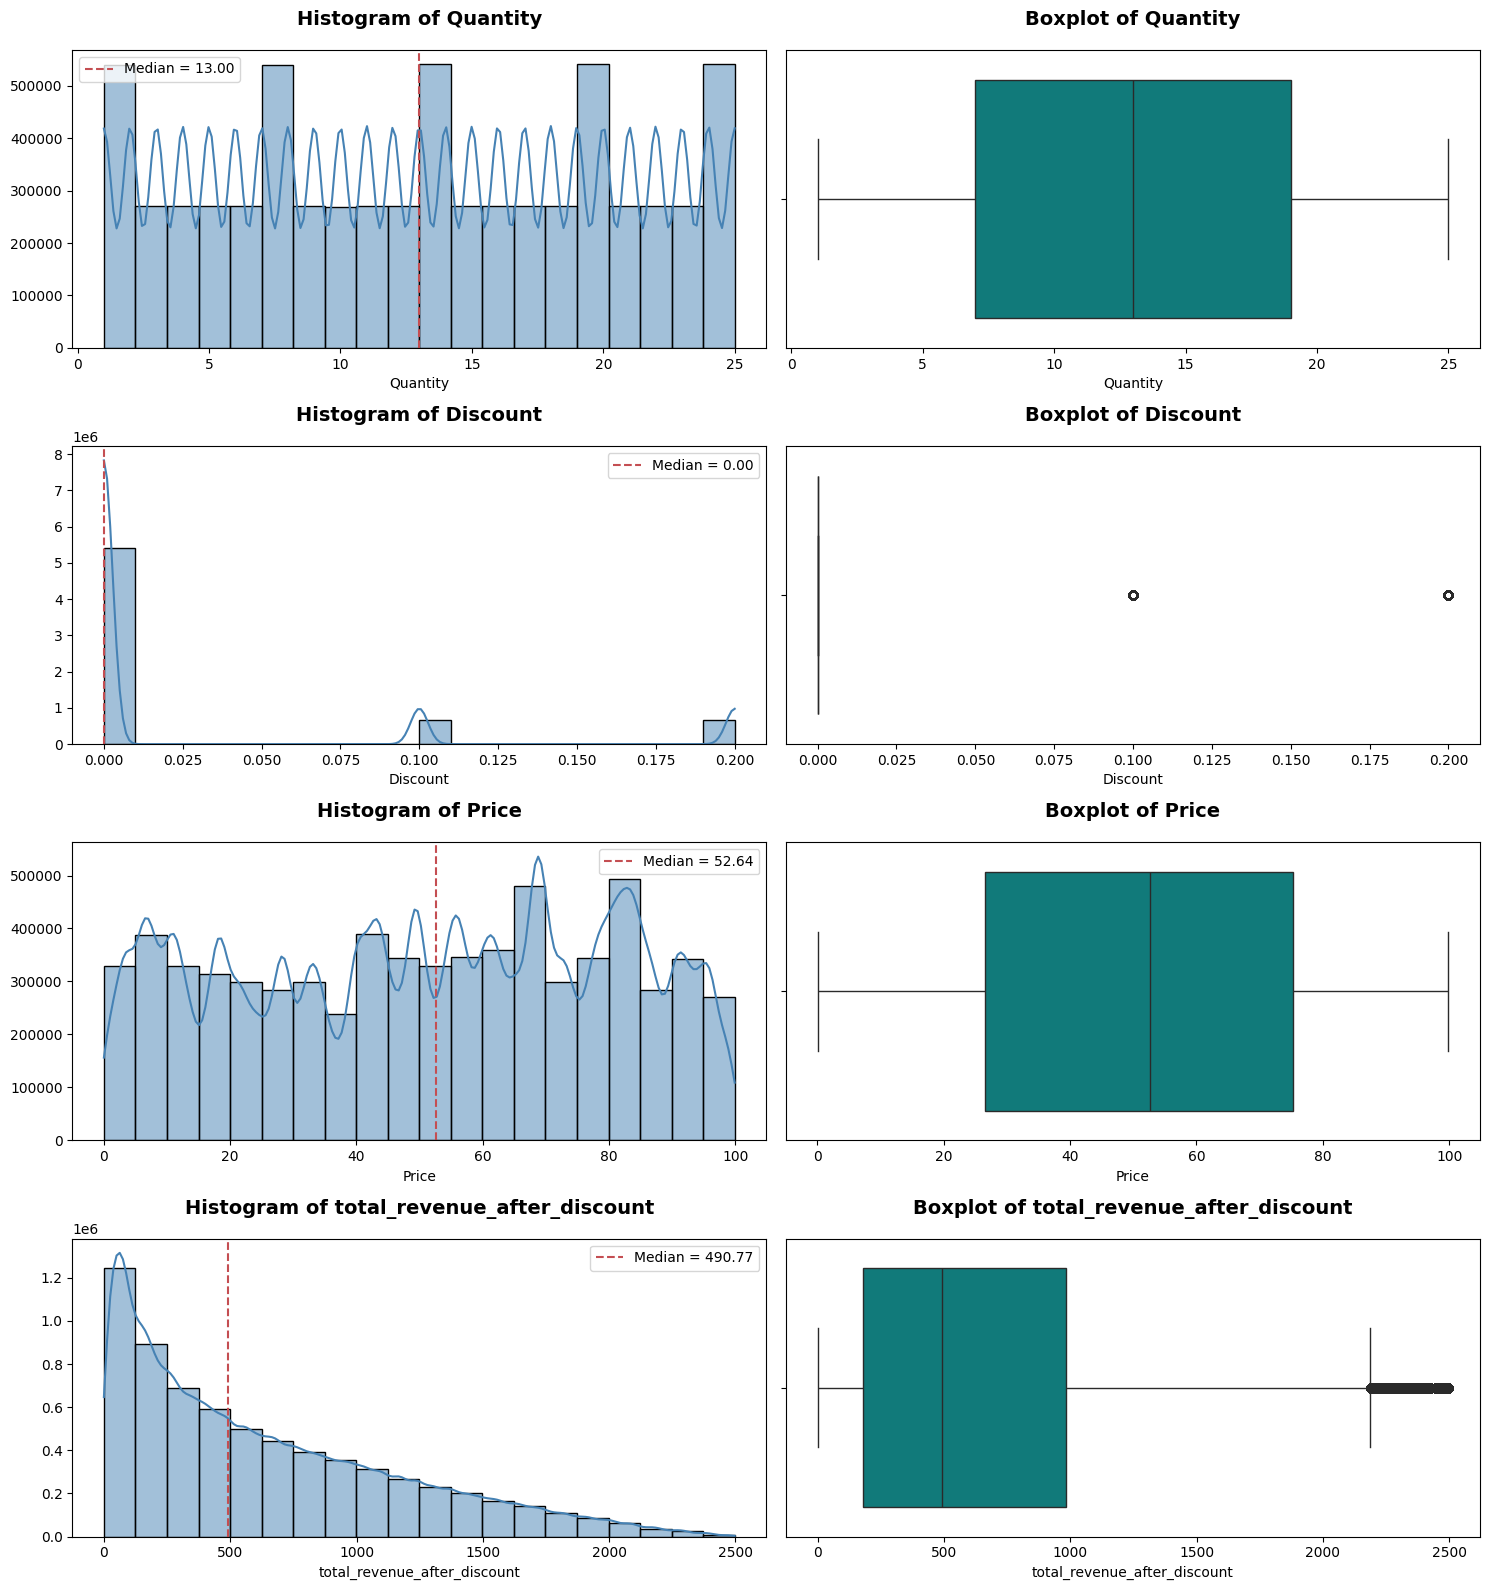

In [ ]:
def plot_numerical_distribution (df: pd.DataFrame, num_features):
    fig, ax = plt.subplots(len(num_features), 2, figsize=(15, len(num_features) * 4))
    ax = np.atleast_2d(ax)
    
    for i, feature in enumerate(num_features):
        # Histogram
        sns.histplot(data=df[feature], bins=20, color="SteelBlue", kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", weight="bold", fontsize=14, pad=18)
        ax[i, 0].axvline(df[feature].median(), color="#C44E52", linestyle="--", label=f"Median = {df[feature].median():.2f}")
        ax[i, 0].set_ylabel("")
        ax[i, 0].legend()

        #Boxplot
        sns.boxplot(data=df[feature], color="DarkCyan", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Boxplot of {feature}", weight="bold", fontsize=14, pad=18)
        ax[i, 1].set_xlabel(feature)
        
    plt.tight_layout()
    plt.show()

num_features = ['Quantity', 'Discount', 'Price','total_revenue_after_discount']
plot_numerical_distribution(df=df, num_features =num_features)
  


In [ ]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: list = None, sort: bool = True):
 
    # If feature list is not provided, automatically select all numerical columns
    if numerical_features is None:
        numerical_features = data.select_dtypes(include=['number']).columns.tolist()

    # Calculate skewness directly for all numerical columns
    skew_series = data[numerical_features].skew(skipna=True)
    skew_df = pd.DataFrame({'Skewness': skew_series})

    # Categorize skewness (Remark) based on the absolute value of Skewness
    def categorize_skew(val):
        abs_val = abs(val)
        if abs_val > 1:
            return "Highly skewed"
        elif abs_val > 0.5:
            return "Moderately skewed"
        else:
            return "Approximately symmetric"

    skew_df['Remark'] = skew_df['Skewness'].apply(categorize_skew)

    # Sort by absolute skewness in descending order if sort=True
    if sort:
        skew_df = skew_df.reindex(skew_df['Skewness'].abs().sort_values(ascending=False).index)

    # Get the list of highly skewed features (|skew| > 1)
    highly_skewed_features = skew_df[skew_df['Skewness'].abs() > 1].index.tolist()

    # ===== Summary Header =====
    print(f"\n========================================================================")
    print(f"Skewness analysis for: {dataset_name}")
    print(f"Total numerical features checked: {len(skew_df)}")
    print(f"========================================================================")

    # ===== Detailed Table =====
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-" * 70)
    for feature, row in skew_df.iterrows():
        print(f"{feature:<30} | {row['Skewness']:>+10.4f} | {row['Remark']}")
    print("-" * 70)

    # ===== Summary Insight =====
    if highly_skewed_features:
        print(f"{len(highly_skewed_features)} feature(s) are highly skewed (|skew| > 1):")
        print(f"   -> {highly_skewed_features}")
    else:
        print("No highly skewed features detected.")
    print(f"========================================================================\n")

    return highly_skewed_features

In [31]:
highly_skewed_cols = check_skewness(df, "Data Retail", numerical_features = num_features)

print("Checking skewness successfully completed.")


Skewness analysis for: Data Retail
Total numerical features checked: 4
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Discount                       |    +1.9212 | Highly skewed
total_revenue_after_discount   |    +0.9130 | Moderately skewed
Price                          |    -0.1159 | Approximately symmetric
Quantity                       |    -0.0007 | Approximately symmetric
----------------------------------------------------------------------
1 feature(s) are highly skewed (|skew| > 1):
   -> ['Discount']

Checking skewness successfully completed.


**Insight**
- Quantity (skew ≈ -0.00, Median = 13.00) $\rightarrow$ Perfectly symmetric; order quantities are uniformly distributed across discrete values from 1 to 25.
- Discount (skew ≈ +1.92, Median = 0.00) $\rightarrow$ Highly right-skewed; most orders receive zero discount, with higher promotional rates (10%, 20%) applied rarely.
- Price (skew ≈ -0.12, Median = 52.64) $\rightarrow$ Approximately symmetric; product prices are evenly spread across the range (0–100).
- total_revenue_after_discount (skew ≈ +0.91, Median = 490.77) $\rightarrow$ Moderately right-skewed; most purchases cluster at lower values, and only a few orders generate high revenue.



## 6.3. Correlation heatmap of numeric features

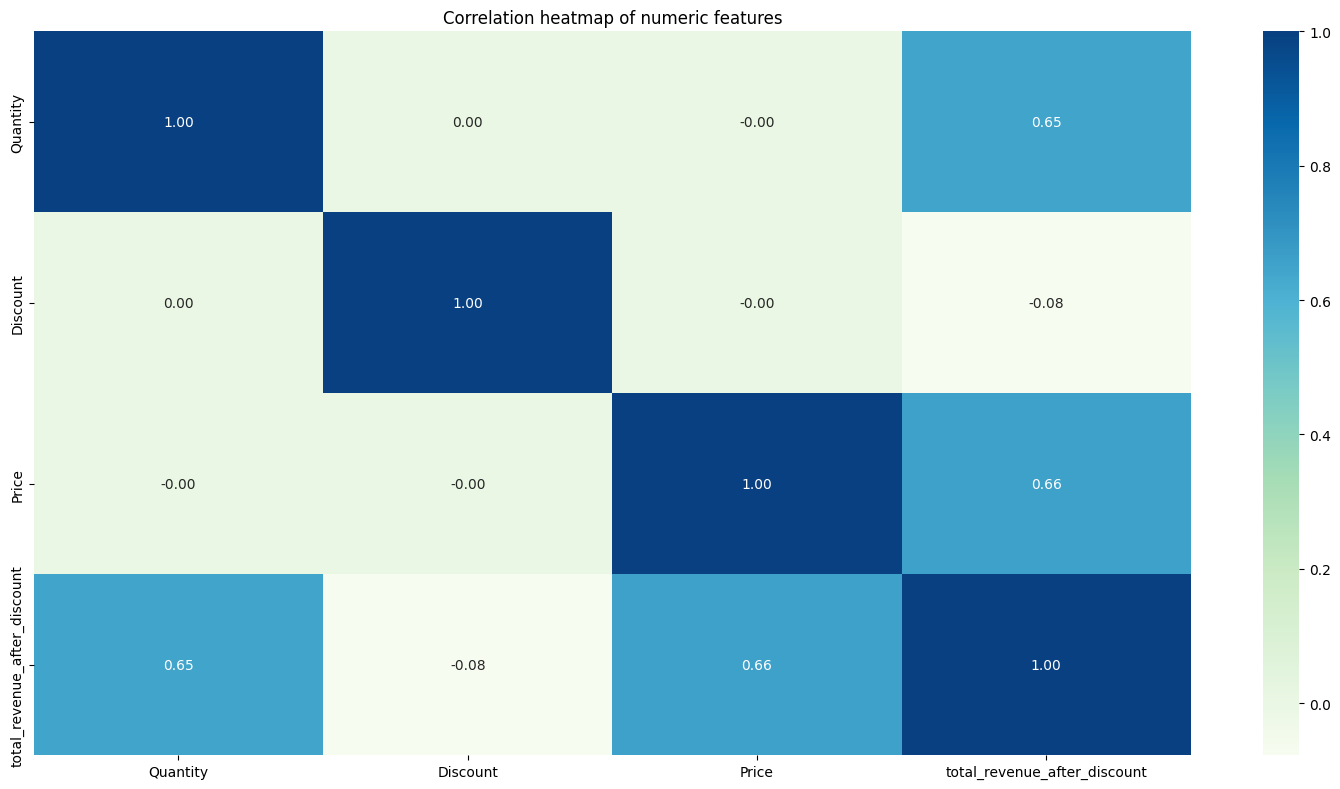

In [32]:
# Calculated the correlation matrix for these numeric features
df_corr = df[num_features].corr()

# Visualization
plt.figure(figsize=(15,8))

sns.heatmap(
    df_corr,
    annot= True,
    fmt='.2f',
    cmap='GnBu'
)

plt.title('Correlation heatmap of numeric features')
plt.tight_layout()
plt.show()

**Insight**
- Revenue is strongly influenced by both Price (0.66) and Quantity (0.65), indicating that pricing decisions and sales volume impact revenue almost equally.
- Quantity has virtually no correlation with price, that price changes do not linearly affect the quantity sold in this dataset.
- Discount has a very small, almost negligible, inverse correlation with revenue.

## 6.3. Revenue Performance

### Monthly Revenue

,year_month,total_revenue_after_discount,total_revenue_mtd
0,2018-01,"1,030,735,897.00","1,030,735,897.00"
1,2018-02,"929,204,217.48","1,959,940,114.48"
2,2018-03,"1,032,200,775.73","2,992,140,890.21"
3,2018-04,"997,268,501.06","3,989,409,391.27"
4,2018-05,"299,832,435.92","4,289,241,827.19"


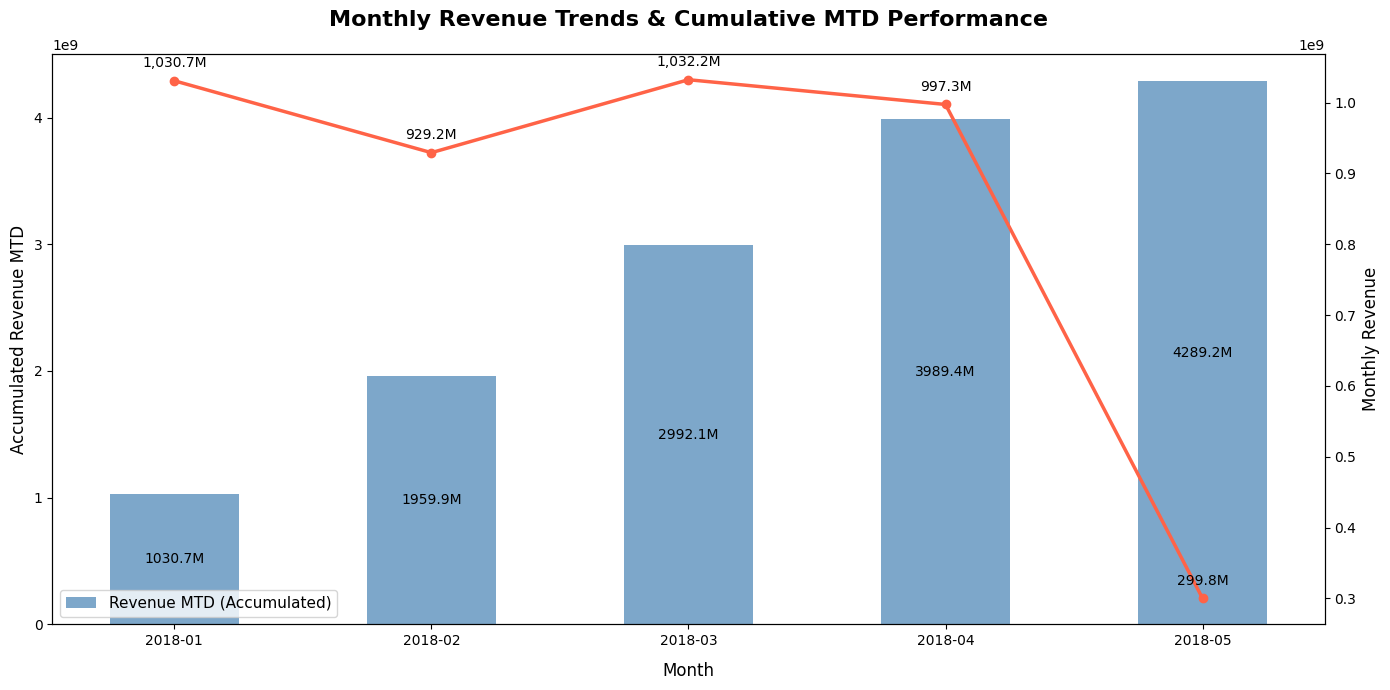

In [33]:
df["year_month"] = df["SalesDate"].dt.to_period("M").astype(str)
df_revenues_monthly = df.copy()

# Aggregate monthly revenue
df_revenues_monthly = (
    df_revenues_monthly.groupby("year_month")
    .agg({"total_revenue_after_discount": "sum"})
    .reset_index()
)

# Compute accumulated revenue
df_revenues_monthly["total_revenue_mtd"] = df_revenues_monthly[
    "total_revenue_after_discount"
].cumsum(axis=0)
display(df_revenues_monthly)


# Visualization
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Bar chart
bars = ax1.bar(
    df_revenues_monthly["year_month"],
    df_revenues_monthly["total_revenue_mtd"],
    color='steelblue',
    alpha=0.7,
    width=0.5,
    label="Revenue MTD (Accumulated)",
)
ax1.set_xlabel("Month", fontsize=12, labelpad=10)
ax1.set_ylabel("Accumulated Revenue MTD", fontsize=12)

# Data label for bar chart
labels_in_m = [
    f"{x / 1e6:.1f}M" for x in df_revenues_monthly["total_revenue_mtd"]
]
ax1.bar_label(bars, labels=labels_in_m, label_type="center", fontsize=10,)

# 2. Line Chart
ax2 = ax1.twinx()
ax2.plot(
    df_revenues_monthly["year_month"],
    df_revenues_monthly["total_revenue_after_discount"],
    marker="o",
    linewidth=2.5,
    color='tomato',
    label="Monthly Revenue",
)
ax2.set_ylabel("Monthly Revenue", fontsize=12)


# Data label for line chart
for x, y in zip(
    df_revenues_monthly["year_month"],
    df_revenues_monthly["total_revenue_after_discount"],
):
    ax2.annotate(
        f"{y/1e6:,.1f}M",
        xy=(x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10,
    )

# General display
plt.title("Monthly Revenue Trends & Cumulative MTD Performance", fontsize=16, pad=20, weight="bold")
ax1.legend(loc="lower left", fontsize=11)

plt.tight_layout()
plt.show()

In [34]:
display(df[df['year_month'] == '2018-05']['SalesDate'].min())
display(df[df['year_month'] == '2018-05']['SalesDate'].max())

Timestamp('2018-05-01 00:00:07.610000')

Timestamp('2018-05-09 23:59:59.400000')

**Insight**
- Monthly revenue remained strong and steady around ~$1.0B/month.
- Revenue of 2018-05 dropped significantly because the data only covered the period from 01 to 09/05/2018.

### Weekly revenue

In [35]:
# 1. Define orders of weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Change the column 'sales_weekday' to 'Categorical' type with the defined order
df['sales_weekday'] = pd.Categorical(
    df['sales_weekday'],
    categories=weekday_order,
    ordered=True
)

# 3. Sort DataFrame by the defined order
df = df.sort_values('sales_weekday')


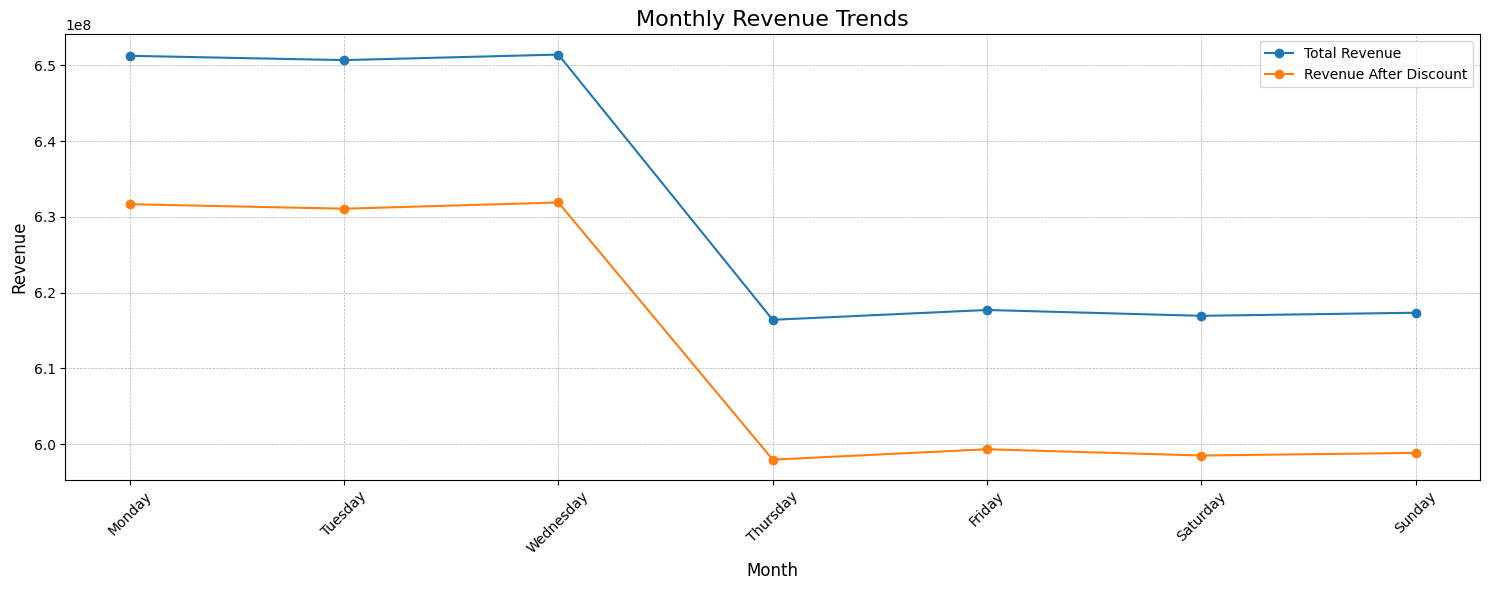

In [36]:
df_revenues_weekly = df.copy()

# Aggregate weekly revenue: 
df_revenues_weekly = (
    df_revenues_weekly
    .groupby("sales_weekday")
    .agg({
        'total_revenue': 'sum',
        'total_revenue_after_discount': 'sum'
    })
    .reset_index()
)

# Visualize with line chart
plt.figure(figsize=(15,6))

plt.plot(
    df_revenues_weekly['sales_weekday'], 
    df_revenues_weekly['total_revenue'], 
    marker='o', 
    linestyle='-', 
    label='Total Revenue'
)
plt.plot(
    df_revenues_weekly['sales_weekday'], 
    df_revenues_weekly['total_revenue_after_discount'], 
    marker='o', 
    linestyle='-', 
    label='Revenue After Discount'
)


plt.title('Monthly Revenue Trends', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()  

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

**Insight**
- Revenue from Monday to Wednesday are higher than on other weekdays, indicating that customers tend to shop more during this time.

### Revenue distribution of categories by month

CategoryName,Beverages,Cereals,Confections,Dairy,Grain,Meat,Poultry,Produce,Seafood,Shell fish,Snails
year_month,,,,,,,,,,,
2018-01,"87,044,892.29","101,202,044.32","132,815,141.64","84,041,019.19","77,379,039.98","117,126,752.39","104,779,706.31","87,453,191.88","78,656,103.37","71,287,777.66","88,950,227.96"
2018-02,"78,851,074.55","91,660,789.56","119,022,995.20","76,122,994.87","69,764,752.60","105,350,958.73","94,272,649.27","78,989,326.02","71,061,573.48","64,122,966.72","79,984,136.47"
2018-03,"87,405,642.15","102,170,027.87","132,593,219.49","84,391,018.50","76,999,348.14","117,513,943.47","104,739,610.64","87,914,184.42","78,516,319.27","71,640,346.60","88,317,115.21"
2018-04,"84,170,286.45","98,297,573.41","128,067,528.89","81,779,414.96","74,125,696.23","113,668,025.67","101,459,715.66","84,760,157.96","76,149,653.28","69,089,639.16","85,700,809.38"
2018-05,"25,415,764.67","29,794,319.91","38,865,310.55","24,415,222.77","22,357,977.62","34,267,238.10","30,570,020.35","25,399,161.68","22,815,167.27","20,540,815.26","25,391,437.74"


CategoryName,Beverages,Cereals,Confections,Dairy,Grain,Meat,Poultry,Produce,Seafood,Shell fish,Snails
year_month,,,,,,,,,,,
2018-01,8.44,9.82,12.89,8.15,7.51,11.36,10.17,8.48,7.63,6.92,8.63
2018-02,8.49,9.86,12.81,8.19,7.51,11.34,10.15,8.50,7.65,6.90,8.61
2018-03,8.47,9.90,12.85,8.18,7.46,11.38,10.15,8.52,7.61,6.94,8.56
2018-04,8.44,9.86,12.84,8.20,7.43,11.40,10.17,8.50,7.64,6.93,8.59
2018-05,8.48,9.94,12.96,8.14,7.46,11.43,10.20,8.47,7.61,6.85,8.47


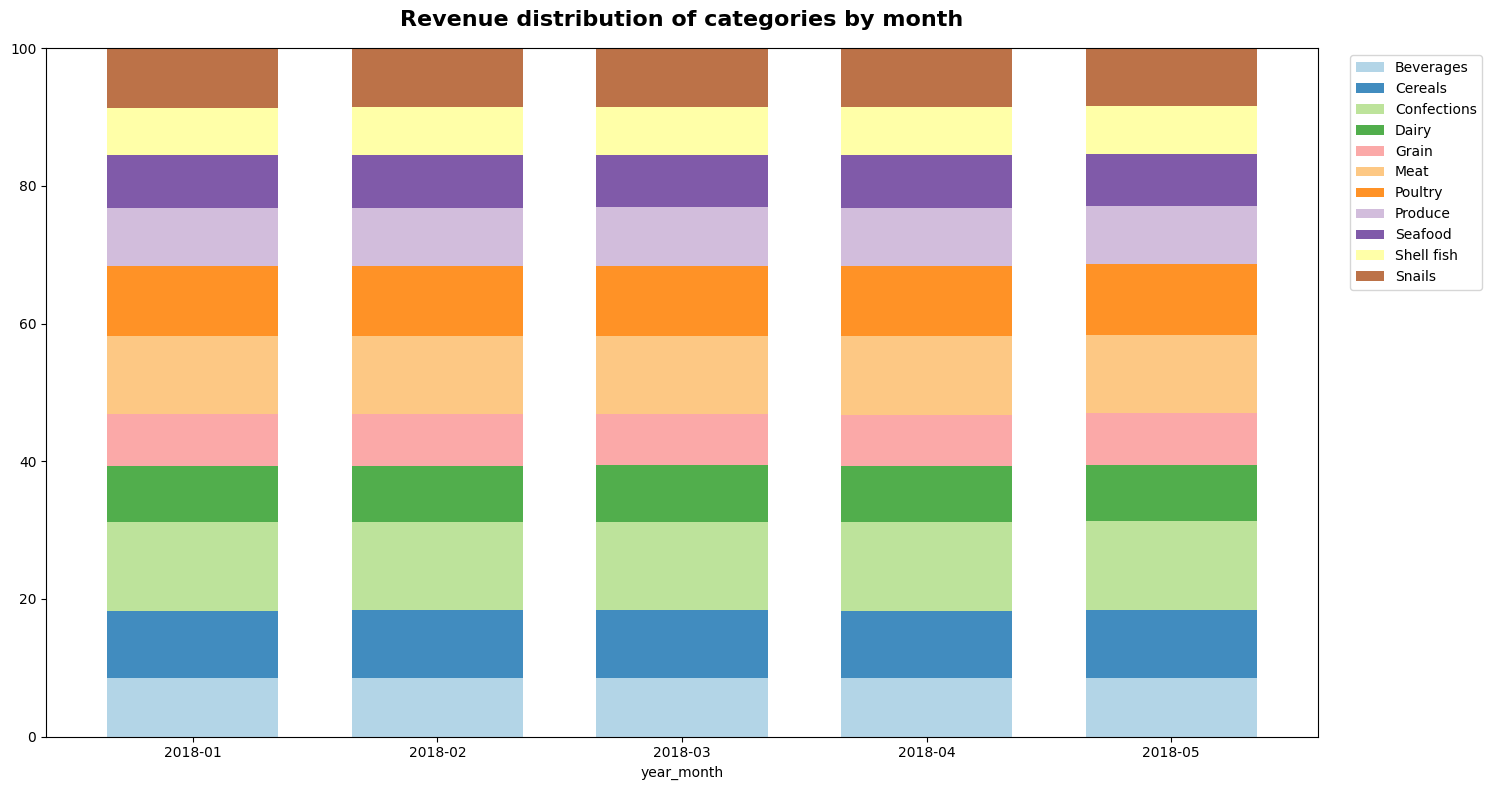

In [37]:

df_revenues_categories_by_month= df.copy()

#Aggregate Revenue of categories by months: 
pivot_revenues = (
    df_revenues_categories_by_month
    .pivot_table(
        index='year_month',
        columns='CategoryName',
        values='total_revenue_after_discount',
        aggfunc='sum',
        fill_value=0
    )
)

# Percent of each category by month
pivot_percent = round(pivot_revenues.div(pivot_revenues.sum(axis=1), axis=0)*100, 2)
pivot_percent.index = pivot_percent.index.astype(str)

display(pivot_revenues)
display(pivot_percent)
# 100% stacked columns chart

fig, ax1 = plt.subplots(figsize=(15,8))

pivot_percent.plot.bar(stacked=True, ax=ax1, alpha=0.85, colormap='Paired', width=0.7)
ax1.set_title("Revenue distribution of categories by month", weight="bold", fontsize=16, pad = 16)
ax1.set_ylabel("")
ax1.set_ylim(0,100)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xticks(rotation=0)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


Which product category (CategoryName) is driving sales for the entire chain?
- Top 3 categories with the largest revenue share are: Confections, Meat, and Poultry.

## 6.4. Product Performance

### Top & Bottom 10 products by revenue

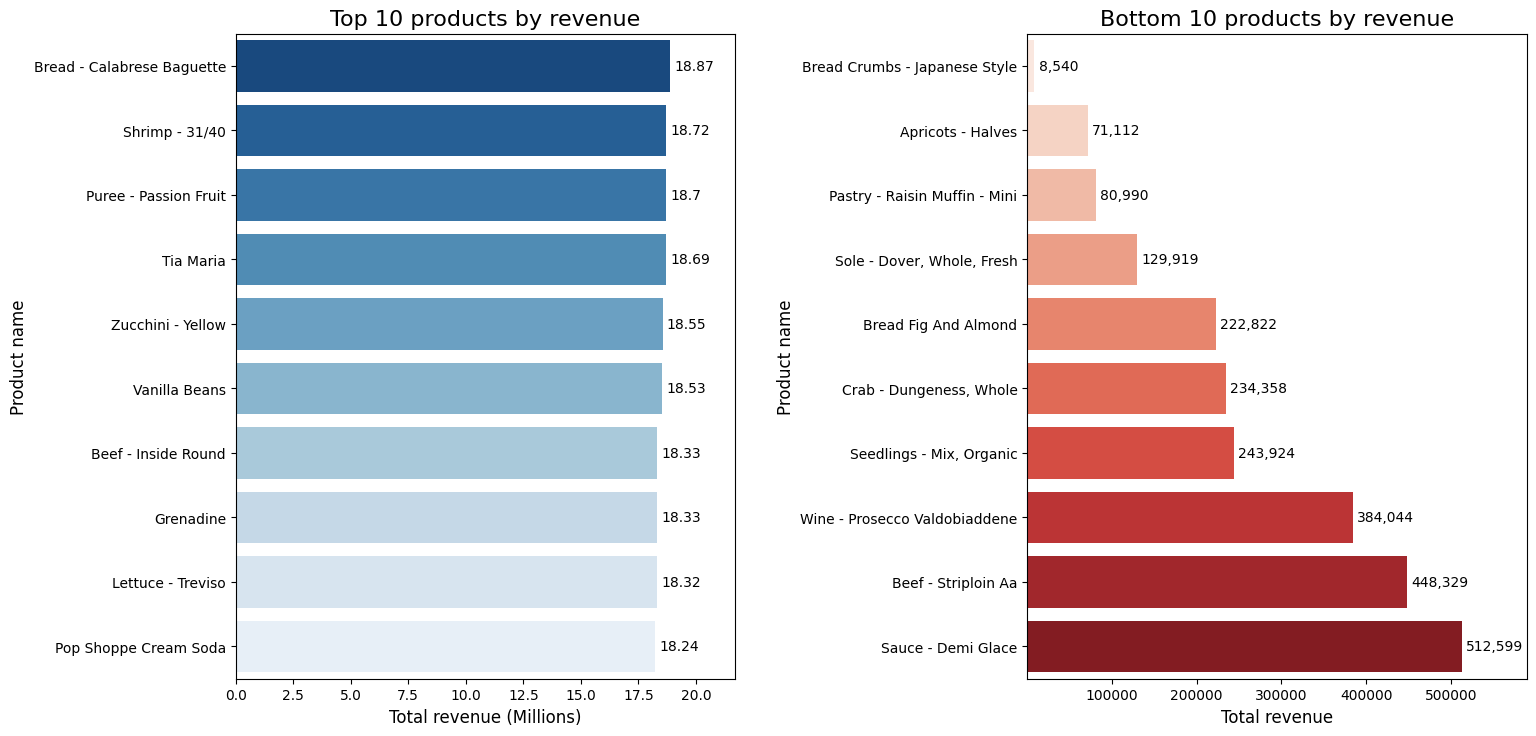

In [38]:
df_revenue = df.copy()

# Aggregate revenue month to date: 
df_revenue = (
    df_revenue
    .groupby("ProductName")
    .agg({
        'total_revenue_after_discount': 'sum'
    })
    .sort_values(by='total_revenue_after_discount', ascending=False)
    .reset_index()
)

df_revenue['total_revenue_after_discount_millions'] = round(df_revenue['total_revenue_after_discount']/1e6, 2)


# Top 10 products by revenue MTD
top_product = df_revenue.nlargest(10, 'total_revenue_after_discount_millions')
bottom_product = df_revenue.nsmallest(10, 'total_revenue_after_discount')

fig, ax= plt.subplots(1, 2, figsize=(16,8))

# Plot 1: Bar chart Top 10 products by revenue
sns.barplot(
    top_product,
    x='total_revenue_after_discount_millions',
    y='ProductName',
    palette='Blues_r',
    ax=ax[0]
)
ax[0].set_title('Top 10 products by revenue', fontsize=16)
ax[0].set_xlabel('Total revenue (Millions)', fontsize=12)
ax[0].set_ylabel('Product name', fontsize=12)

# Data labels
for container in ax[0].containers: 
    ax[0].bar_label(container, fontsize=10, padding=3)

max_val_top = top_product["total_revenue_after_discount_millions"].max()
ax[0].set_xlim(0, max_val_top * 1.15)

# Plot 2: Bar chart Bottom 10 products by revenue
sns.barplot(
    bottom_product,
    x='total_revenue_after_discount',
    y='ProductName',
    palette='Reds',
    ax=ax[1]
)
ax[1].set_title('Bottom 10 products by revenue', fontsize=16)
ax[1].set_xlabel('Total revenue', fontsize=12)
ax[1].set_ylabel('Product name', fontsize=12)

# Data labels
for container in ax[1].containers: 
    ax[1].bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)
max_val_bottom = bottom_product["total_revenue_after_discount"].max()
ax[1].set_xlim(1, max_val_bottom * 1.15)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

**Insight**
- Top 10 products generate remarkably balanced high revenues between 18.24M and 18.87M, led by Bread - Calabrese Baguette.
- Bottom 10 products show a large revenue difference at a much lower level, dropping to a low of 8,540 for Bread Crumbs - Japanese Style.

### Top & Bottom 10 products by quantity

,ProductName,Quantity
0,Yoghurt Tubes,199724
1,Longos - Chicken Wings,199679
2,"Thyme - Lemon, Fresh",198567
3,Onion Powder,198163
4,Cream Of Tartar,198126
...,...,...
447,Cocktail Napkin Blue,190597
448,Bacardi Breezer - Tropical,190532
449,"Nut - Pistachio, Shelled",190465
450,Liners - Baking Cups,190370


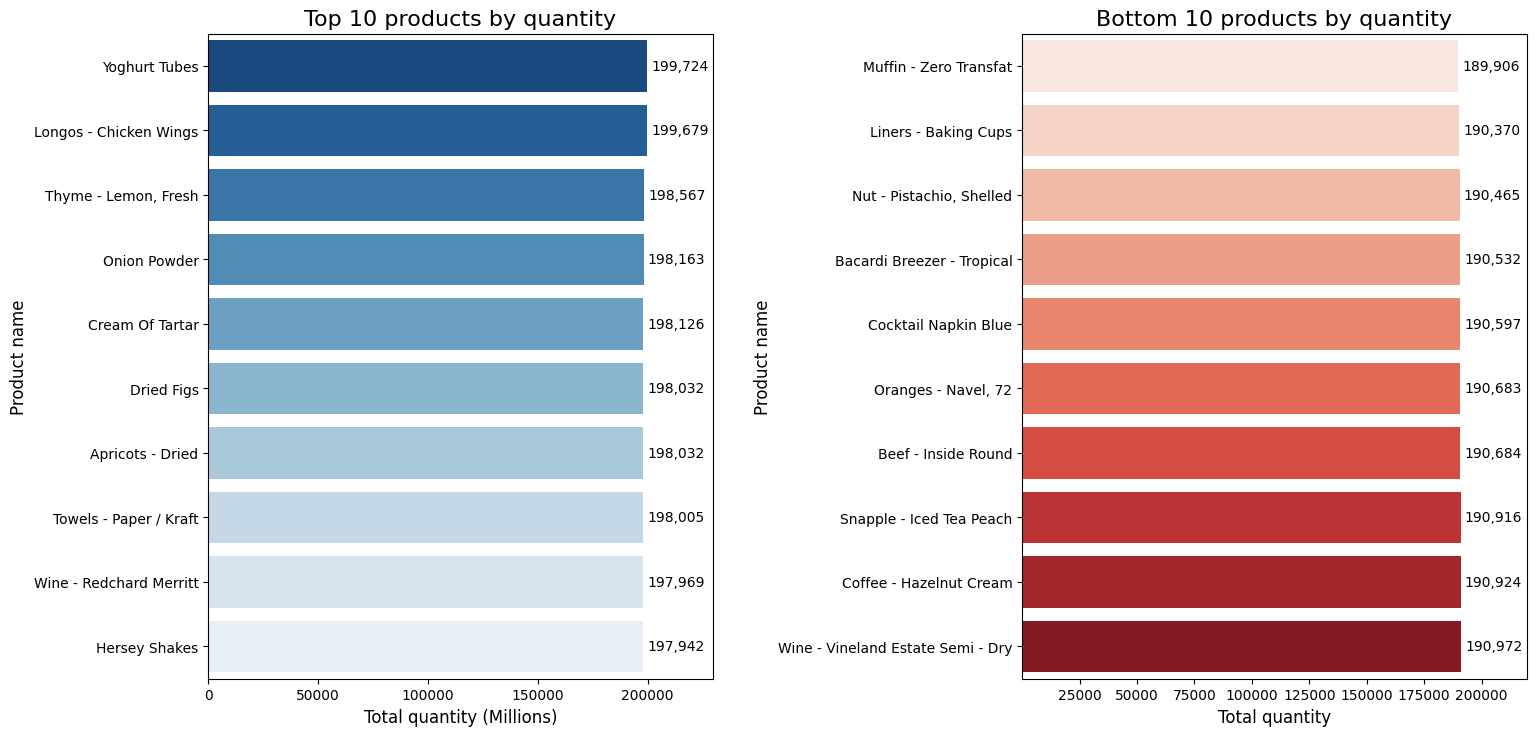

In [39]:
df_quantity_mtd = df.copy()

#Aggregate quantity month to date: 
df_quantity_mtd = (
    df_quantity_mtd
    .groupby("ProductName")
    .agg({
        'Quantity': 'sum',
    })
    .sort_values(by='Quantity', ascending=False)
    .reset_index()
)

display(df_quantity_mtd)

# Top 10 products by quantity MTD
top_product = df_quantity_mtd.nlargest(10, 'Quantity')
bottom_product = df_quantity_mtd.nsmallest(10, 'Quantity')

fig, ax= plt.subplots(1, 2, figsize=(16,8))

# Plot 1: Bar chart Top 10 products by quantity
sns.barplot(
    top_product,
    x='Quantity',
    y='ProductName',
    palette='Blues_r',
    ax=ax[0]
)
ax[0].set_title('Top 10 products by quantity', fontsize=16)
ax[0].set_xlabel('Total quantity (Millions)', fontsize=12)
ax[0].set_ylabel('Product name', fontsize=12)

# Data labels
for container in ax[0].containers: 
    ax[0].bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)

max_val_top = top_product["Quantity"].max()
ax[0].set_xlim(0, max_val_top * 1.15)

# Plot 2: Bar chart Bottom 10 products by quantity
sns.barplot(
    bottom_product,
    x='Quantity',
    y='ProductName',
    palette='Reds',
    ax=ax[1]
)
ax[1].set_title('Bottom 10 products by quantity', fontsize=16)
ax[1].set_xlabel('Total quantity', fontsize=12)
ax[1].set_ylabel('Product name', fontsize=12)

# Data labels
for container in ax[1].containers: 
    ax[1].bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)
max_val_bottom = bottom_product["Quantity"].max()
ax[1].set_xlim(1, max_val_bottom * 1.15)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

**Insight**
- Product sales volumes are nearly equal across all items (~190K–200K units), meaning the difference in total revenue is mostly due to price rather than demand.

### Correlation Quantity & Revenue by category



,CategoryName,Quantity,total_revenue_after_discount,total_revenue_after_discount_millions
0,Beverages,7393693,"366,515,024.01",366.52
1,Cereals,8735296,"427,393,431.91",427.39
2,Confections,11078474,"556,930,717.35",556.93
3,Dairy,6815143,"354,358,156.77",354.36
4,Grain,5433152,"323,879,126.65",323.88
5,Meat,9719292,"492,888,844.69",492.89
6,Poultry,9159847,"440,025,564.97",440.03
7,Produce,8368793,"368,243,613.01",368.24
8,Seafood,6996152,"330,527,987.47",330.53
9,Shell fish,6983457,"299,598,294.03",299.60


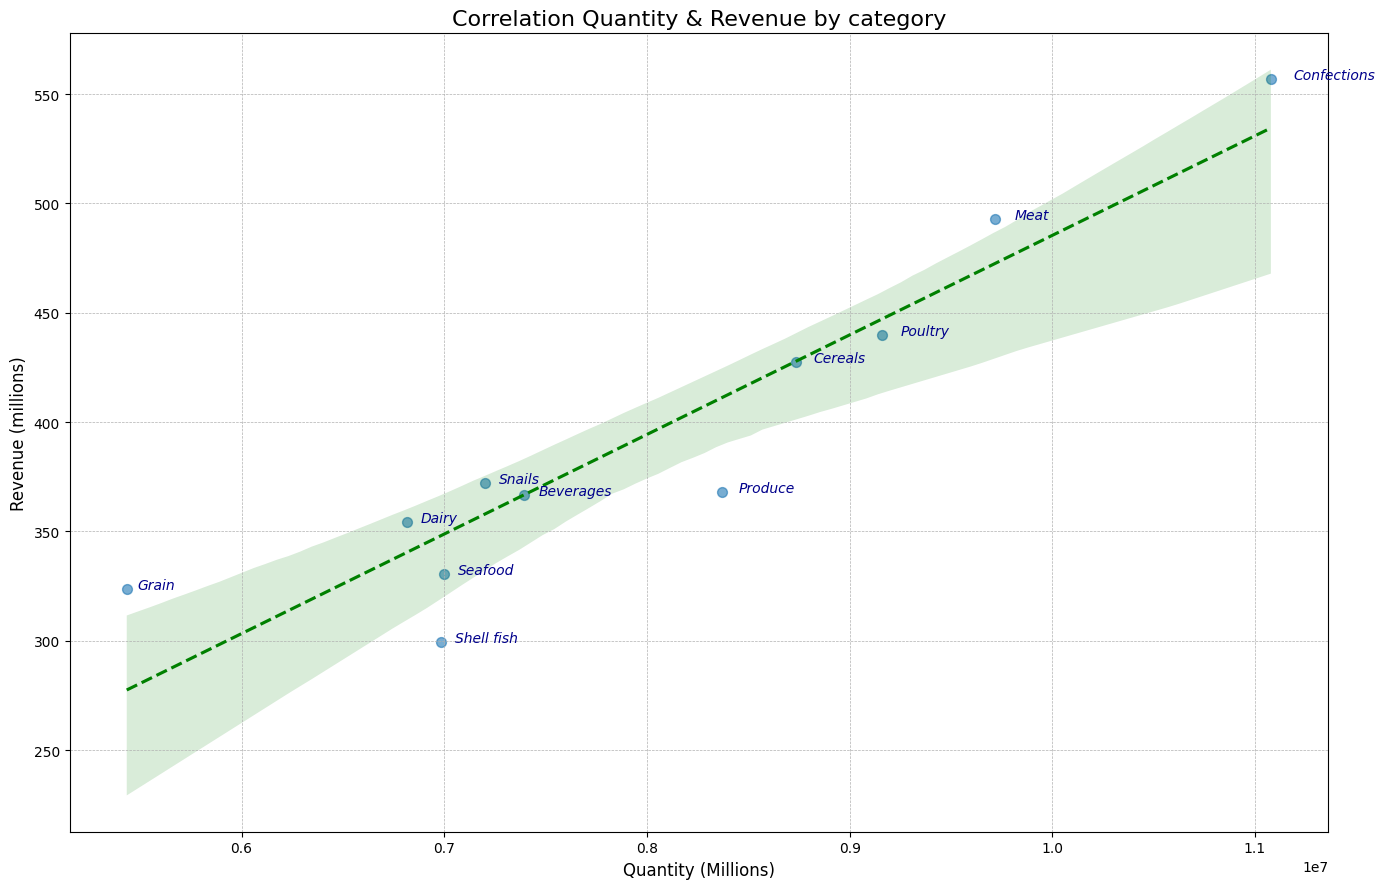

In [40]:
df_correlation = df.copy()

#Aggregate quantity & revenue by categories: 
df_correlation = (
    df_correlation
    .groupby("CategoryName")
    .agg({
        'Quantity': 'sum',
        'total_revenue_after_discount': 'sum'
    })
    # .sort_values(by='Quantity', ascending=False)
    .reset_index()
)
df_correlation['total_revenue_after_discount_millions'] = (
    round(df_correlation['total_revenue_after_discount']/1000000, 2)
)

display(df_correlation)

# Visualize wwith scatter plot
plt.figure(figsize=(14,9))

ax = sns.regplot(
    df_correlation,
    x='Quantity',
    y='total_revenue_after_discount_millions',
    scatter_kws={'alpha': 0.6, 's': 50},
    line_kws={'color': 'green', 'linestyle': '--'}
)
ax.set_title('Correlation Quantity & Revenue by category', fontsize=16)
ax.set_xlabel('Quantity (Millions)', fontsize=12)
ax.set_ylabel('Revenue (millions)', fontsize=12)


for index, row in df_correlation.iterrows():
    ax.text(
        x=row['Quantity'] * 1.01, 
        y=row['total_revenue_after_discount_millions'], 
        s=row['CategoryName'],             
        fontsize=10,
        fontstyle='italic',
        color='darkblue' 
    )

plt.grid(False, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

**Insight**
- Overall revenue increases with sales volume, led by Confections and Meat in total value.
- Produce is clearly below the trendline, which means that even though it sells a lot, its average price point and profit margin are smaller.

### Correlation Quantity & Revenue by product



,ProductName,Quantity,total_revenue_after_discount
0,Anchovy Paste - 56 G Tube,194811,"7,732,400.41"
1,"Appetizer - Mini Egg Roll, Shrimp",196353,"1,361,246.55"
2,Appetizer - Mushroom Tart,197048,"7,426,265.77"
3,Appetizer - Sausage Rolls,195960,"9,166,584.36"
4,Apricots - Dried,198032,"16,890,400.57"
...,...,...,...
447,Yeast Dry - Fermipan,191891,"13,773,317.77"
448,Yoghurt Tubes,199724,"16,270,010.65"
449,"Yogurt - Blueberry, 175 Gr",191711,"5,000,018.52"
450,Yogurt - French Vanilla,191615,"13,654,514.67"


,ProductName,Quantity,total_revenue_after_discount
1,"Appetizer - Mini Egg Roll, Shrimp",196353,"1,361,246.55"
2,Appetizer - Mushroom Tart,197048,"7,426,265.77"
5,Apricots - Halves,196533,"71,112.31"
22,Beans - Kidney White,196935,"8,863,572.81"
46,Beer - Sleemans Cream Ale,197583,"5,470,735.74"
50,Black Currants,197614,"7,850,542.32"
57,Bread - English Muffin,196058,"6,562,877.34"
105,Chips Potato Salt Vinegar 43g,196574,"8,845,768.27"
138,Dc - Frozen Momji,196901,"3,273,666.15"
149,Ezy Change Mophandle,196576,"9,409,009.35"


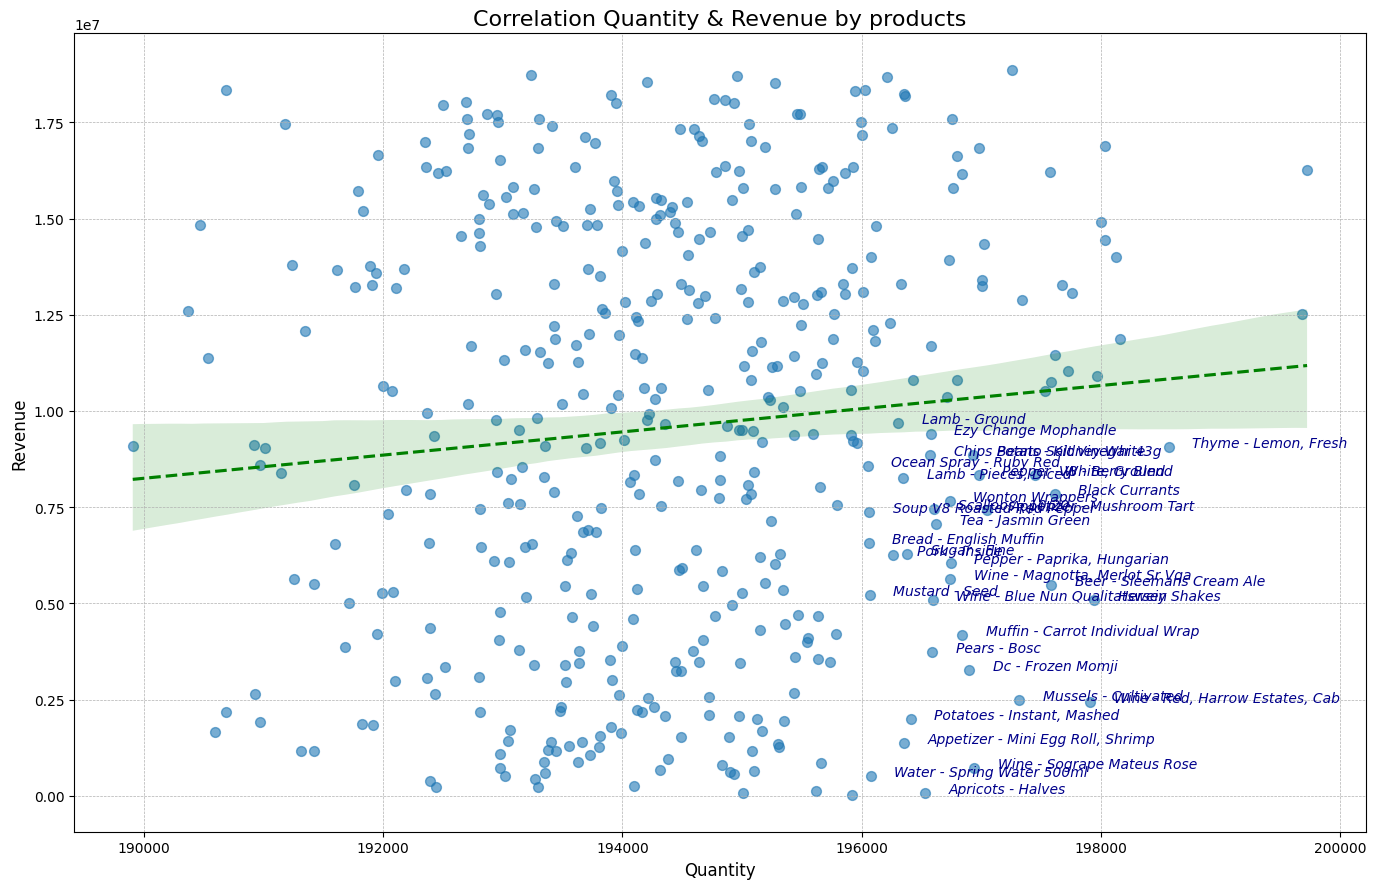

In [41]:
df_correlation_product= df.copy()

#Aggregate quantity & revenue by categories: 
df_correlation_product = (
    df_correlation_product
    .groupby("ProductName")
    .agg({
        'Quantity': 'sum',
        'total_revenue_after_discount': 'sum'
    })
    # .sort_values(by='Quantity', ascending=False)
    .reset_index()
)
display(df_correlation_product)

# Visualize wwith scatter plot
plt.figure(figsize=(14,9))


ax = sns.regplot(
    df_correlation_product,
    x='Quantity',
    y='total_revenue_after_discount',
    scatter_kws={'alpha': 0.6, 's': 50},
    line_kws={'color': 'green', 'linestyle': '--'}
)
ax.set_title('Correlation Quantity & Revenue by products', fontsize=16)
ax.set_xlabel('Quantity', fontsize=12)
ax.set_ylabel('Revenue', fontsize=12)

list_product = df_correlation_product[
    (df_correlation_product['Quantity']>= 196000) 
    & (df_correlation_product['total_revenue_after_discount']<= 10000000)]

display(list_product)
for index, row in list_product.iterrows():
    ax.text(
        x=row['Quantity']* 1.001,  # Đặt vị trí văn bản lệch một chút về bên phải điểm
        y=row['total_revenue_after_discount'], # Giữ nguyên vị trí y
        s=row['ProductName'],              # Nội dung văn bản là tên category
        fontsize=10,
        fontstyle='italic',
        color='darkblue' # Dùng màu khác để nhãn nổi bật
    )

plt.grid(False, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

**Insight**
- Quantity and revenue show a weak correlation and significant price differences between products.
- Bottom-right products have huge demand but bring in very low revenue.

**Conclusion:**
- A strong positive trend at the macro level (Category) completely disappears at the micro level (Product), proving that category performance is driven by the volume of product, while individual product performance is driven by price.

In [42]:
# 1. Define orders of Class
class_order = ['Low', 'Medium', 'High']

# 2. Change the column 'Class' to 'Categorical' type with the defined order
df['Class'] = pd.Categorical(
    df['Class'],
    categories=class_order,
    ordered=True
)

# 3. Sort DataFrame by the defined order
df = df.sort_values('Class')


,Class,Quantity,total_revenue_after_discount
0,Low,29.75,"1,456.12"
1,Medium,30.31,"1,413.20"
2,High,27.82,"1,463.12"


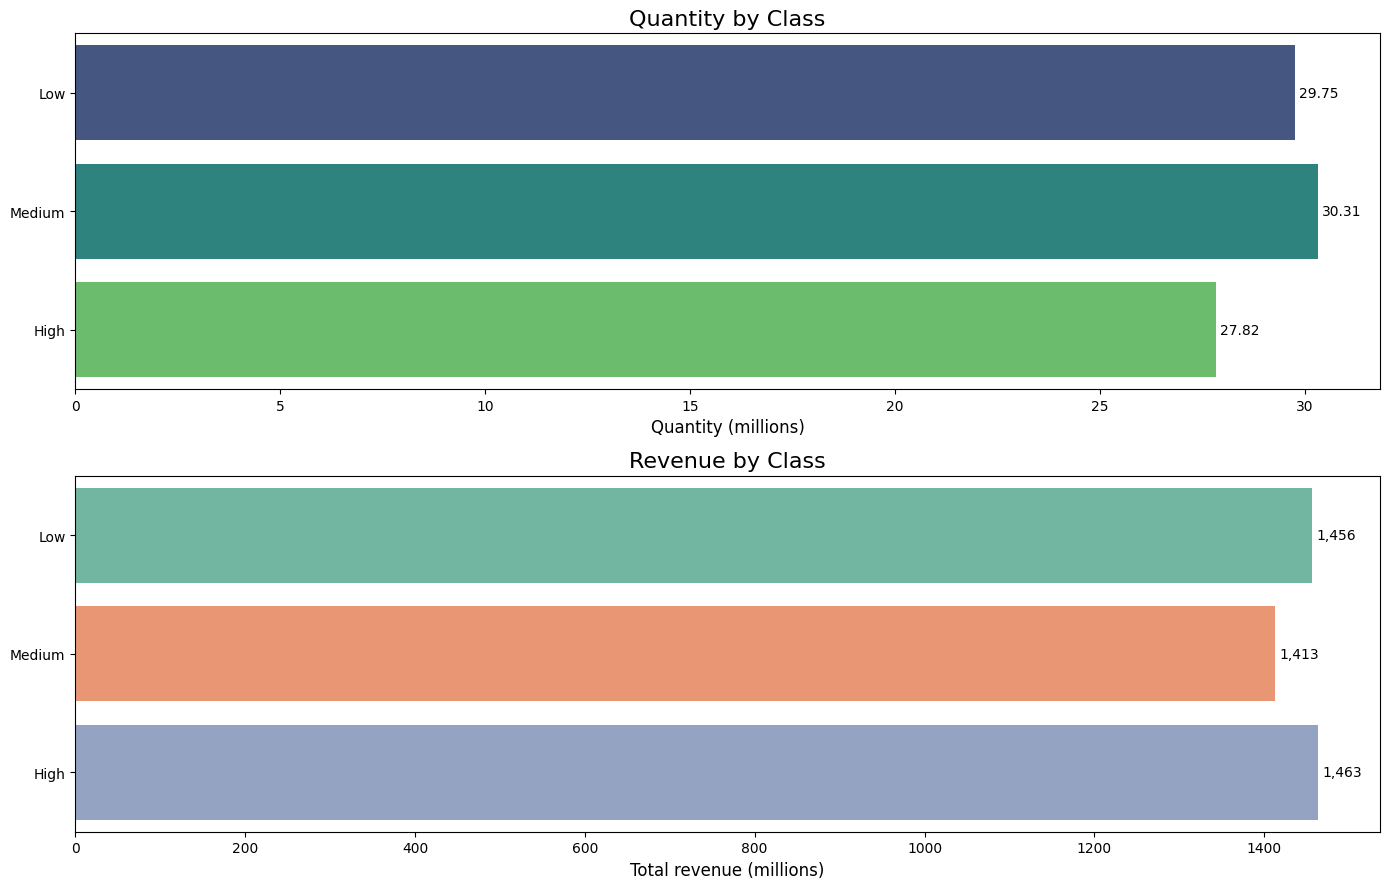

In [43]:
df_class= df.copy()

#Aggregate quantity & revenue by categories: 
df_class = (
    df_class
    .groupby("Class")
    .agg({
        'Quantity': 'sum',
        'total_revenue_after_discount': 'sum'
    })
    # .sort_values(by='Quantity', ascending=False)
    .reset_index()
)


for i in df_class.select_dtypes(include=np.number).columns: 
    df_class[i] = round(df_class[i]/1000000, 2)

display(df_class)

# Visualize with bar chart
plt.figure(figsize=(14,9))

ax1 = plt.subplot(2,1,1)

sns.barplot(
    df_class,
    x='Quantity',
    y='Class',
    palette='viridis',
)


ax1.set_title('Quantity by Class', fontsize=16)
ax1.set_xlabel('Quantity (millions)', fontsize=12)
ax1.set_ylabel('')

for container in ax1.containers: 
    ax1.bar_label(container, fontsize=10, padding=3)

    
ax2 = plt.subplot(2,1,2)

sns.barplot(
    df_class,
    x='total_revenue_after_discount',
    y='Class',
    palette='Set2',
)


ax2.set_title('Revenue by Class', fontsize=16)
ax2.set_xlabel('Total revenue (millions)', fontsize=12)
ax2.set_ylabel('')

for container in ax2.containers: 
    ax2.bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)


plt.tight_layout()
plt.show()


**Insight**
- All three classes contributed equally to the system, each holding about 1/3 of total volume and revenue.
- High Class generated the highest revenue ($1,463M) despite selling the fewest products (27.82M).
- Medium Class sold the highest sales volume (30.31M) but bringed the lowest revenue ($1,413M).

## 6.5. Customer Behavior

### Customer segment by total spend

,CustomerID,customer_name,total_spend,Segment
0,1,Stefanie Y Frye,"3,263.56",Bronze
1,2,Sandy T Kirby,"3,397.89",Bronze
2,3,Lee T Zhang,"3,327.79",Bronze
3,4,Regina S Avery,"3,122.56",Bronze
4,5,Daniel S Mccann,"2,650.35",Bronze
...,...,...,...,...
98754,98755,Yvette C Campos,"83,969.23",Plantinum
98755,98756,Angelo X Mc Millan,"96,193.34",Plantinum
98756,98757,Shari J Prince,"87,530.48",Plantinum
98757,98758,Stuart K Cameron,"78,206.08",Plantinum


,number_customers,total_spend,average_spend_per_customer
Segment,,,
Plantinum,24690,"1,911,277,470.00","77,411.00"
Gold,24690,"1,318,339,699.00","53,396.00"
Silver,24689,"806,147,134.00","32,652.00"
Bronze,24690,"296,681,343.00","12,016.00"


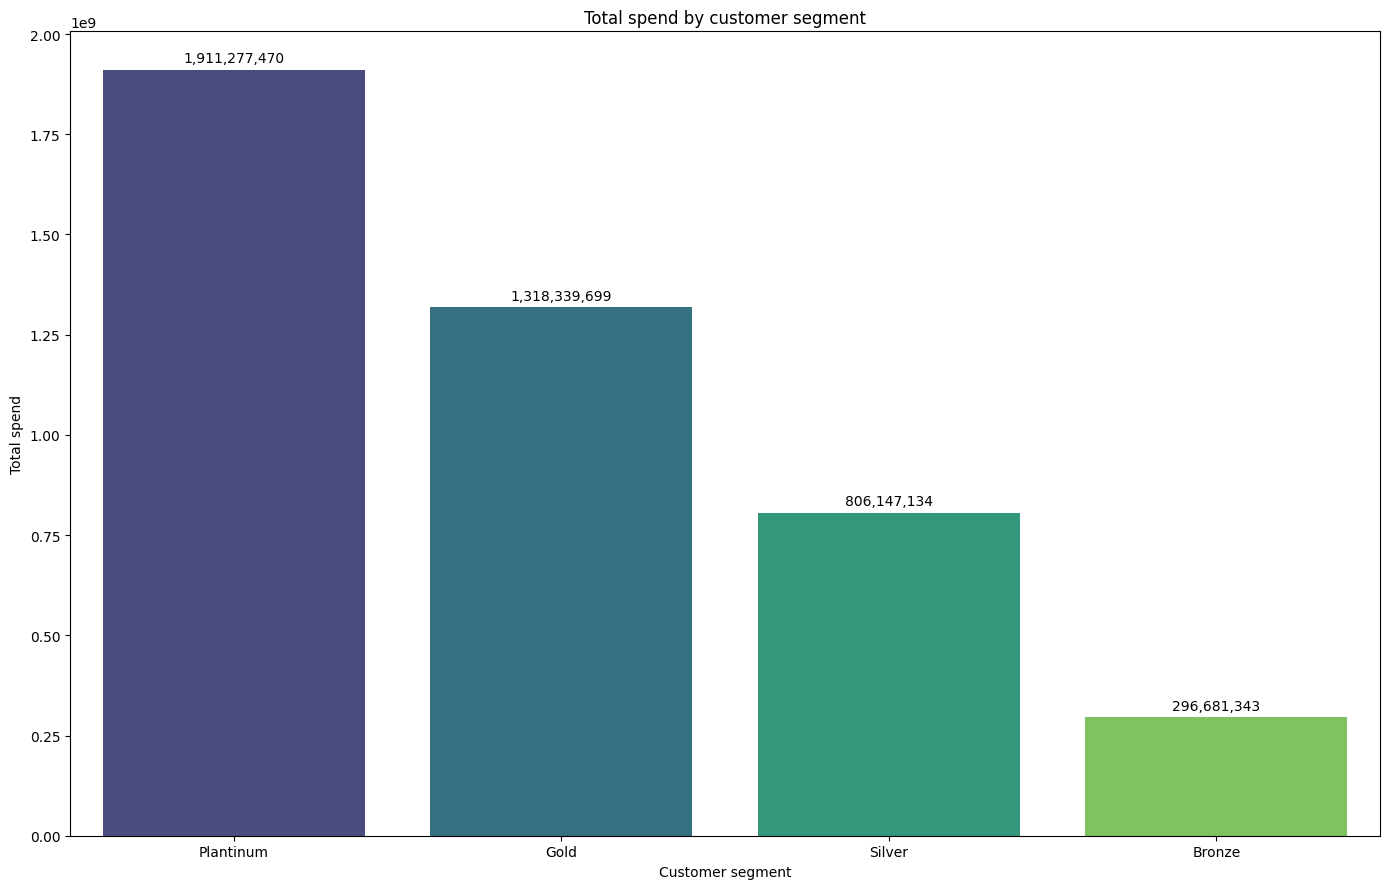

In [44]:
df_customer_seg_spend= df.copy()

#Aggregate total spend of customers: 
df_customer_seg_spend = (
    df_customer_seg_spend
    .groupby('CustomerID')
    .agg(
        customer_name = ('full_name_customer', 'max'),
        total_spend = ('total_revenue_after_discount', 'sum')
    )
    .reset_index()
)

s_quartiles = df_customer_seg_spend['total_spend'].quantile([0.75, 0.5, 0.25])

def segment(value, s_quartiles):
    if value >= s_quartiles[0.75]:
        return 'Plantinum'
    elif value >= s_quartiles[0.5]:
        return 'Gold'
    elif value >= s_quartiles[0.25]:
        return 'Silver'
    else: 
        return 'Bronze'

df_customer_seg_spend['Segment'] = df_customer_seg_spend['total_spend'].apply(lambda x: segment(x, s_quartiles))
display (df_customer_seg_spend)

df_segment = (
    df_customer_seg_spend
    .groupby('Segment')
    .agg(
        number_customers = ('CustomerID', 'count'),
        total_spend = ('total_spend', 'sum'),
        average_spend_per_customer = ('total_spend', 'mean')
    )
    .sort_values(by ='total_spend', ascending=False)
)

df_segment[["total_spend", "average_spend_per_customer"]] = round(
    df_segment[["total_spend", "average_spend_per_customer"]], 0
)

display (df_segment)

# Visualize with  bar chart
plt.figure(figsize=(14,9))

ax = sns.barplot(
    data=df_segment.reset_index(), 
    x='Segment',                   
    y='total_spend',               
    palette='viridis'            
)

# Add data labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', fontsize=10, padding=3)

plt.title('Total spend by customer segment')
plt.xlabel('Customer segment')
plt.ylabel('Total spend')

plt.xticks(rotation=0)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Insight**
- Customers are divided into four equal groups (~24,690 each), but total revenue is heavily skewed toward high-value tiers, with Platinum generating over 6.4x the revenue of Bronze.

## 6.6. Top and Bottom 10 Salesperson by revenue

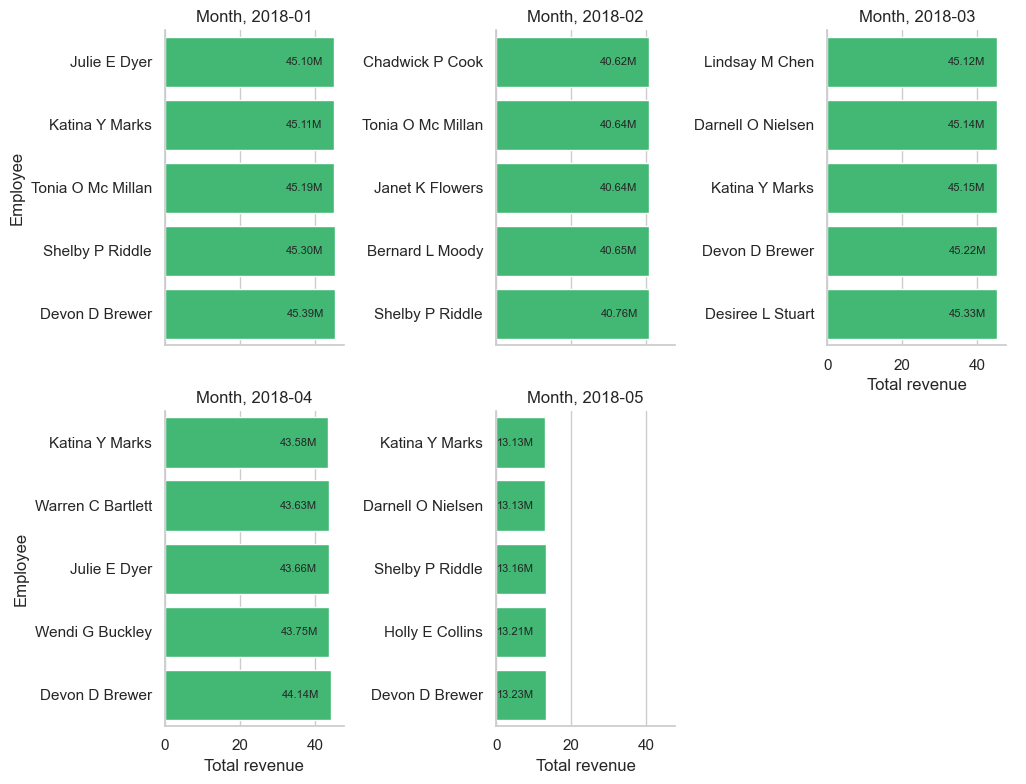

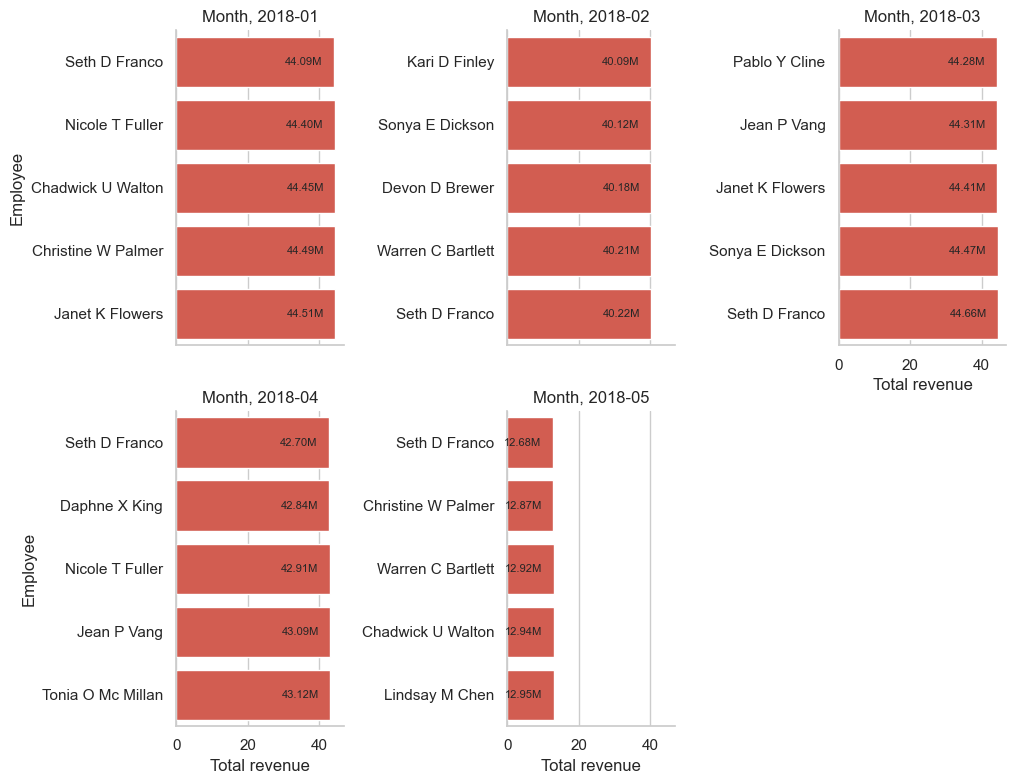

In [45]:
df_employees_summary= df.copy()

#Aggregate revenue by Salesperson: 
df_employees_summary = (
    df_employees_summary
    .groupby(['year_month', 'SalesPersonID', 'full_name_employee'] )
    .agg(
        
        total_revenue = ('total_revenue_after_discount', 'sum')
    )
    .sort_values(by=['year_month', 'total_revenue'], ascending=[True, False])
    .reset_index()
)

df_employees_summary['total_revenue_million'] = df_employees_summary['total_revenue']/1e6

df_employees_summary['rank_top'] = df_employees_summary.groupby('year_month')['total_revenue_million'].rank(method='dense', ascending=False)
df_employees_summary['rank_bottom'] = df_employees_summary.groupby('year_month')['total_revenue_million'].rank(method='dense', ascending=True)


# Filter for the top 5 and bottom 5 sort the results
df_top5_salespersons = df_employees_summary[df_employees_summary['rank_top'] <= 5].sort_values(['year_month', 'rank_top'], ascending=[True, False])


df_bottom5_salespersons = df_employees_summary[df_employees_summary['rank_bottom'] <= 5].sort_values(['year_month', 'rank_bottom'], ascending=[True, True])



# Visualize with bar chart
def plot_bars (data, title, color):
    sns.set_theme(style= 'whitegrid')

    g = sns.catplot(
        data = data,
        y='full_name_employee',
        x='total_revenue_million',
        col='year_month',
        col_wrap=3,
        kind='bar',
        color=color,
        sharey=False,
        height=4,
        aspect=0.85
    )

    

# Add data labels to the bars
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='{:,.2f}M', fontsize=8, padding=-35, label_type="edge",)

    g.set_axis_labels('Total revenue', 'Employee')
    g.set_titles(col_template='Month, {col_name}')
    
    plt.tight_layout()
    plt.show()

plot_bars(df_top5_salespersons, 'Top 5 Salespersons by month', color='#2ecc71')

plot_bars(df_bottom5_salespersons, 'Bottom 5 Salespersons by month', color='#e74c3c')



**Insight**
- Overall sales performance across all employees is exceptionally high and balanced; even the Bottom 5 group ($40M–$44M from Jan to Apr) trails the Top 5 by only $1M–$2M per month.
- Devon D Brewer is the primary revenue driver, whereas Seth D Franco repeatedly falls into the Bottom 5 across multiple months.
- Monthly revenue remains remarkably stable from January through April ($40M–$45M per person), followed by a sharp drop in May 2018 due to incomplete monthly data cutoff.

## 6.7. Top and Bottom 10 Cities by revenue

### Top 10 city by revenue

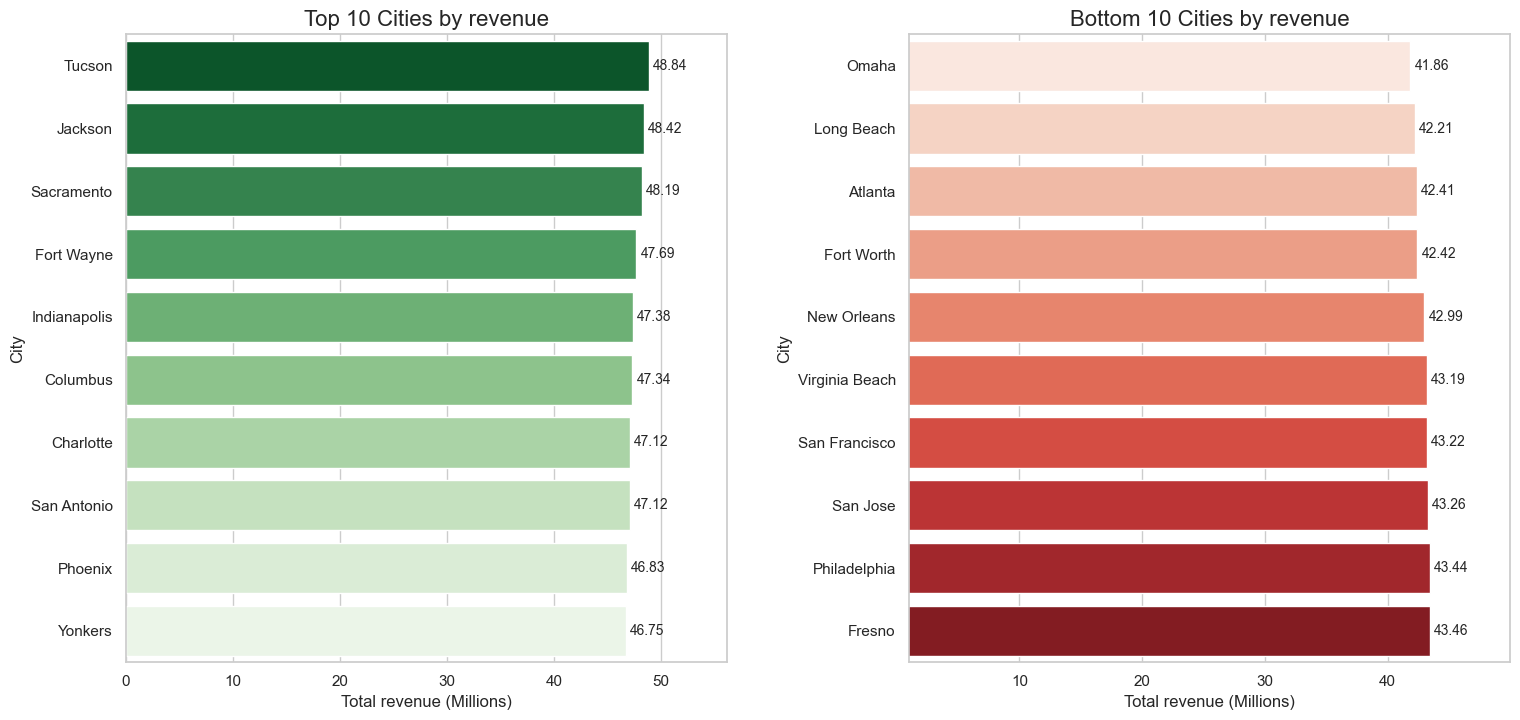

In [46]:
df_revenue_city = df.copy()

# Aggregate revenue by Country/City: 
df_revenue_city = (
    df_revenue_city
    .groupby(['CityName_customer'] )
    .agg(
        
        total_revenue = ('total_revenue_after_discount', 'sum'), # sum up revenue per city
    )
    .sort_values(by=['total_revenue'], ascending=False)
    .reset_index()
)

df_revenue_city['total_revenue_millions'] = round(df_revenue_city['total_revenue']/1e6, 2)

# Top 10 City by revenue
top_10_city = df_revenue_city.nlargest(10, 'total_revenue_millions')
bottom_10_city = df_revenue_city.nsmallest(10, 'total_revenue_millions')

# Visualize with bar chart 
fig, ax= plt.subplots(1, 2, figsize=(16,8))

# Plot 1: Bar chart Top 10 Cities by revenue
sns.barplot(
    top_10_city,
    x='total_revenue_millions',
    y='CityName_customer',
    palette='Greens_r',
    ax=ax[0]
)
ax[0].set_title('Top 10 Cities by revenue', fontsize=16)
ax[0].set_xlabel('Total revenue (Millions)', fontsize=12)
ax[0].set_ylabel('City', fontsize=12)

# Data labels
for container in ax[0].containers: 
    ax[0].bar_label(container, fmt='{:,.2f}', fontsize=10, padding=3)
max_val_top = top_10_city["total_revenue_millions"].max()
ax[0].set_xlim(0, max_val_top * 1.15)


# Plot 2: Bar chart Bottom 10 Cities by revenue
sns.barplot(
    bottom_10_city,
    x='total_revenue_millions',
    y='CityName_customer',
    palette='Reds',
    ax=ax[1]
)
ax[1].set_title('Bottom 10 Cities by revenue', fontsize=16)
ax[1].set_xlabel('Total revenue (Millions)', fontsize=12)
ax[1].set_ylabel('City', fontsize=12)

# Data labels
for container in ax[1].containers: 
    ax[1].bar_label(container, fmt='{:,.2f}', fontsize=10, padding=3)
max_val_bottom = bottom_10_city["total_revenue_millions"].max()
ax[1].set_xlim(1, max_val_bottom * 1.15)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

**Insight**
- Revenue between the top city and bottom city differs by only ~14%, reflecting a highly uniform nationwide demand.
- Even the bottom 10 cities contribute significantly to revenue (over $41 million each), confirming the stable coverage of business operations.

### Total revenue by Cities (Bubble map)

In [47]:
import plotly.express as px
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

df_revenue_city_geo = df_revenue_city.copy()

# Merge df_revenue_city with geopy to create lat & long
unique_cities = df_revenue_city['CityName_customer'].unique()

# Fetch coordinates with GeoPy
geolocator = Nominatim(user_agent="usa_city_mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1) # Delay 1 seconds between requests to avoid rate limit
city_coordinate = []
for city in unique_cities:
    
    location = geocode(f"{city}, USA")
    if location:
        city_coordinate.append({
            'CityName_customer': city,
            'lat': location.latitude,
            'lon': location.longitude
        })
    else:
        city_coordinate.append({
            'CityName_customer': city,
            'lat': None,
            'lon': None
        })
df_city_geo = pd.DataFrame(city_coordinate)

df_revenue_city_geo = pd.merge(
    df_revenue_city_geo,
    df_city_geo,
    on='CityName_customer',
    how='left'
)



In [48]:
# Visualize Bubble map with plotly
fig = px.scatter_geo(
    df_revenue_city_geo,
    lat='lat',
    lon='lon',
    size = 'total_revenue_millions',
    color = 'total_revenue_millions',
    hover_name='CityName_customer',
    hover_data={
            'total_revenue_millions': ':,.2f', 
            'lat': False, 
            'lon': False
        },
    labels={
            "total_revenue_millions": "Revenue "},
    size_max=15,
    scope='usa',
    color_continuous_scale='Blues',
    title='Total revenue by cities'
)

fig.update_layout(
    title_text='Total revenue by cities',
    width=1280,   
    height=720,   
    margin=dict(l=30, r=30, t=50, b=30),
    coloraxis_colorbar=dict(
        title='Revenue (Millions USD)',
        ticksuffix='M'
    )
)

fig.show()

In [49]:
df_quantity_city = df.copy()

# Aggregate revenue by Country/City 
df_quantity_city = (
    df_quantity_city
    .groupby(['CityName_customer'])
    .agg(
        
        total_quantity = ('Quantity', 'sum'), # sum up quantity per city
        total_order = ('SalesID', 'nunique') # count unique orders per city
    )
    .sort_values(by=['total_quantity'], ascending=False)
    .reset_index()
)
df_quantity_city_geo = pd.merge(
    df_quantity_city,
    df_city_geo,
    on='CityName_customer',
    how='left'
)

In [50]:
# Visualize Bubble map with plotly
fig = px.scatter_geo(
    df_quantity_city_geo,
    lat='lat',
    lon='lon',
    size = 'total_quantity',
    color = 'total_quantity',
    hover_name='CityName_customer',
    hover_data={
            'total_quantity': ':,.0f', 
            'lat': False, 
            'lon': False
        },
    labels={
            "total_quantity": "Quantiy "},
    size_max=15,
    scope='usa',
    color_continuous_scale='Blues',
    title='Total quantity by cities'
)

fig.update_layout(
    title_text='Total quantity by cities',
    width=1280,   
    height=720,   
    margin=dict(l=30, r=30, t=50, b=30),
    coloraxis_colorbar=dict(
        title='Quantity'
    )
)

fig.show()

**Insight**
- The cities with the highest revenue (dark blue dots) are also the ones with the largest sales volume, indicating that there are no significant price differences between geographic areas.

## 7. Conclusion

🔍 **Key Insights**

- **Monthly Revenue Trend:**  
  Revenue stays steady at $\approx \$1.0B$/month across Jan–Apr 2018. The drop in May 2018 is caused by partial data logging (May 1–9 only).

- **Pricing & Revenue Drivers:**  
  Individual product sales volume is uniform ($\approx 190K–200K$ units), meaning price is the driver of SKUs revenue. Overall revenue correlates equally with Price and Quantity.

- **Category vs Product:**  
  Category revenue grows directly with sales volume (led by Confections, Meat, Poultry), but product-level revenue depends entirely on price rather than demand volume.

- **Customer Segmentation:**  
  Customer number is evenly split across tiers, but revenue is heavily skewed: Platinum generates over $6.4\times$ the revenue of Bronze.

- **Staff Performance:**  
  Sales team performance is highly consistent ($1M–2M$ gap between top and bottom performers), led by Devon D Brewer ($\approx \$44M/mo$).

- **Regional Performance:**  
  Revenue is balanced nationwide ($\approx \$42M–\$48M$ per city). 



💡 **Recommendations**  

1. **Price Adjustment:** raise prices slightly or bundle low-margin, high-volume SKUs (Produce) with high-class products to boost average order value.

2. **VIP Loyalty Focus:** create exclusive retention and rewards programs for Platinum customers who drive the majority of business growth.

3. **Smart Promotion Timing:** replace flat discounts with targeted upsells/cross-sells on peak shopping days (Monday through Wednesday).

4. **Staff Training:** train lower-performing staff using best practices and sales methods from top performers.